In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
from torch.utils.data import DataLoader, Dataset, TensorDataset, IterableDataset, get_worker_info
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


import numpy as np
import os
import sys
import json

!pip3 install sympy --upgrade

if 'google.colab' in sys.modules and 'cv2' not in sys.modules:
  !pip3 install opencv-python

if 'google.colab' in sys.modules and 'torchmetrics' not in sys.modules:
  !pip3 install torchmetrics


import cv2

if 'google.colab' in sys.modules and 'spectral' not in sys.modules:
    !pip3 install spectral

from spectral import imshow, view_cube
import spectral.io.envi as envi

if 'google.colab' in sys.modules and 'tqdm' not in sys.modules:
    !pip3 install tqdm

%matplotlib inline
from tqdm import tqdm

if 'google.colab' in sys.modules and 'optuna' not in sys.modules:
    !pip3 install optuna

import optuna

if 'google.colab' in sys.modules and 'rasterio' not in sys.modules:
    !pip3 install rasterio

import rasterio

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# To avoid disconnection in Google Colab
# drive.mount('/content/drive', force_remount=True) # ctrl + shift + i
# function preventColabDisconnect() {
#     setInterval(() => {
#         console.log("Preventing disconnect...");
#         document.querySelector("colab-toolbar-button").click();
#     }, 300000); // 300,000 ms = 10 minutes
# }
# preventColabDisconnect();

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 135.3 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 26.4 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# Define the Generator class
# ========================= GENERATORS =========================
class CNNGenerator(nn.Module):
    def __init__(self, input_channels=3, output_channels=9):
        super(CNNGenerator, self).__init__()

        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(512, output_channels, kernel_size=3, padding=1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.conv5(x)
        return x


class UNetGenerator(nn.Module):
    def __init__(self, input_channels, output_channels):
        super(UNetGenerator, self).__init__()

        def down_block(in_c, out_c, apply_batchnorm=True):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=3, stride=2, padding=1, bias=False)]
            if apply_batchnorm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        def up_block(in_c, out_c, apply_dropout=False):
            layers = [nn.ConvTranspose2d(in_c, out_c, kernel_size=3, stride=2, padding=1, bias=False),
                      nn.BatchNorm2d(out_c),
                      nn.ReLU(inplace=True)]
            if apply_dropout:
                layers.append(nn.Dropout(0.5))
            return nn.Sequential(*layers)

        # encoder
        self.down1 = down_block(input_channels, 64, apply_batchnorm=False)
        self.down2 = down_block(64, 128)
        self.down3 = down_block(128, 256)
        self.down4 = down_block(256, 512)
        self.down5 = down_block(512, 512)

        # Decoder
        self.up4 = up_block(512, 512, apply_dropout=True)
        self.up3 = up_block(1024, 256, apply_dropout=True)
        self.up2 = up_block(512, 128, apply_dropout=True)
        self.up1 = up_block(256, 64)


        self.final_layer = nn.ConvTranspose2d(128, output_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1) # uit is 128
        d3 = self.down3(d2) # uit is 256
        d4 = self.down4(d3) # uit is 512
        d5 = self.down5(d4) # uit is 512

        u4 = self.up4(d5)

        diffY = d4.size()[2] - u4.size()[2]
        diffX = d4.size()[3] - u4.size()[3]

        u4 = F.pad(u4, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        u4 = torch.cat([u4, d4], dim=1)
        u3 = self.up3(u4)

        diffY = d3.size()[2] - u3.size()[2]
        diffX = d3.size()[3] - u3.size()[3]

        u3 = F.pad(u3, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        u3 = torch.cat([u3, d3], dim=1)
        u2 = self.up2(u3)

        diffY = d2.size()[2] - u2.size()[2]
        diffX = d2.size()[3] - u2.size()[3]

        u2 = F.pad(u2, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        u2 = torch.cat([u2, d2], dim=1)
        u1 = self.up1(u2)



        diffY = d1.size()[2] - u1.size()[2]
        diffX = d1.size()[3] - u1.size()[3]


        u1 = F.pad(u1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])


        u1 = torch.cat([u1, d1], dim=1)

        return torch.tanh(self.final_layer(u1))





class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                              kernel_size=kernel_size,
                              stride=stride,
                              padding=kernel_size//2)
        self.in1 = nn.InstanceNorm2d(out_channels)
        self.prelu1 = nn.PReLU()

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                              kernel_size=kernel_size,
                              stride=stride,
                              padding=kernel_size//2)
        self.in2 = nn.InstanceNorm2d(out_channels)
        self.prelu2 = nn.PReLU()

        if in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.InstanceNorm2d(out_channels)
            )
        else:
            self.skip = None

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.in1(out)
        out = self.prelu1(out)

        out = self.conv2(out)
        out = self.in2(out)
        out = self.prelu2(out)

        if self.skip is not None:
            residual = self.skip(residual)

        out += residual  * 0.3
        return out


class ResNetGenerator(nn.Module):
    def __init__(self, input_channels=3, output_channels=9):
        super(ResNetGenerator, self).__init__()

        self.initial_conv = nn.Sequential(
            nn.Conv2d(input_channels, 1024, kernel_size=5, stride=1, padding=2),
            nn.PReLU()
        )

        self.compress_conv = nn.Sequential(
            nn.Conv2d(1024, 256, kernel_size=3, stride=1, padding=1),
            nn.PReLU()
        )

        self.res_block1 = ResidualBlock(256, 256, kernel_size=3)
        self.res_block2 = ResidualBlock(256, 256, kernel_size=3)

        self.skip_path = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=7, stride=1, padding=3),
            nn.PReLU()
        )

        self.expand_conv1 = nn.Sequential(
            nn.Conv2d(256, 1024, kernel_size=3, stride=1, padding=1),
            nn.PReLU()
        )
        self.expand_conv2 = nn.Sequential(
            nn.Conv2d(1024, output_channels, kernel_size=5, stride=1, padding=2),
            nn.PReLU()
        )

    def forward(self, x):
        out_initial = self.initial_conv(x)
        out_compress = self.compress_conv(out_initial)
        out_main1 = self.res_block1(out_compress)
        out_main2 = self.res_block2(out_main1)

        out_skip = self.skip_path(x)

        out1 = self.expand_conv1(out_main2 + out_compress)

        if out1.size() != out_initial.size():
            diffY = out_initial.size()[2] - out1.size()[2]
            diffX = out_initial.size()[3] - out1.size()[3]
            out1 = F.pad(out1, [diffX // 2, diffX - diffX // 2,
                                diffY // 2, diffY - diffY // 2])

        out2 = self.expand_conv2(out1 + out_initial)

        if out2.size() != out_skip.size():
            diffY = out_skip.size()[2] - out2.size()[2]
            diffX = out_skip.size()[3] - out2.size()[3]
            out2 = F.pad(out2, [diffX // 2, diffX - diffX // 2,
                                diffY // 2, diffY - diffY // 2])

        return out2 + out_skip



class GeneratorLarge(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GeneratorLarge, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=3, stride=2, padding=2)
        self.conv2 = nn.Conv1d(in_channels=100, out_channels=50, kernel_size=3, stride=2, padding=2)
        self.conv3 = nn.Conv1d(in_channels=50, out_channels=10, kernel_size=3, stride=2, padding=2)

        self.fc = nn.Sequential(
            nn.Linear(3 * 10, 2048),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(2048, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(2048, 4096),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(4096, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(4096, 2048),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(2048, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(2048, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = self.conv3(x)
        x = nn.functional.relu(x)


        x = x.view(x.size(0), -1)
        hyperspectral_data = self.fc(x)



        return hyperspectral_data


class GeneratorLarge_MI_PCA(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GeneratorLarge_MI_PCA, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=3, stride=2, padding=2)
        self.conv2 = nn.Conv1d(in_channels=100, out_channels=50, kernel_size=3, stride=2, padding=2)
        self.conv3 = nn.Conv1d(in_channels=50, out_channels=10, kernel_size=3, stride=2, padding=2)

        self.fc = nn.Sequential(
            nn.Linear(5 * 10, 2048),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(2048, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(2048, 4096),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(4096, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(4096, 2048),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(2048, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(2048, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = self.conv3(x)
        x = nn.functional.relu(x)


        x = x.view(x.size(0), -1)
        hyperspectral_data = self.fc(x)



        return hyperspectral_data


class GeneratorLarge_bandwidth(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GeneratorLarge_bandwidth, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=100, kernel_size=3, stride=2, padding=2)
        self.conv2 = nn.Conv1d(in_channels=100, out_channels=50, kernel_size=3, stride=2, padding=2)
        self.conv3 = nn.Conv1d(in_channels=50, out_channels=10, kernel_size=3, stride=2, padding=2)

        self.fc = nn.Sequential(
            nn.Linear(9 * 10, 2048),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(2048, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(2048, 4096),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(4096, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(4096, 2048),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(2048, momentum=0.4),
            nn.Dropout(0.5),

            nn.Linear(2048, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)


        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = self.conv3(x)
        x = nn.functional.relu(x)


        x = x.view(x.size(0), -1)
        hyperspectral_data = self.fc(x)



        return hyperspectral_data

# Generator Network (MLP)
class GeneratorMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GeneratorMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, output_dim)
        )

    def forward(self, x):
        return self.model(x)



# ========================= DISCRIMINATORS =========================
# Discriminator Network (MLP)
class DiscriminatorMLP(nn.Module):
    def __init__(self, input_channels, output_channels):
        super(DiscriminatorMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_channels+output_channels, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, rgb_image, multispectral_image):
        x = torch.cat((rgb_image, multispectral_image), dim=1)
        return self.model(x)



class PatchGANDiscriminator(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(PatchGANDiscriminator, self).__init__()

        self.features = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(input_channels + output_channels, input_channels + output_channels, kernel_size=3, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),

            nn.utils.spectral_norm(nn.Conv2d(input_channels + output_channels, 512, kernel_size=3, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
        )


        self.patch_output = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(512, 1, kernel_size=3, stride=3, padding=0)),
            nn.LeakyReLU(0.2, inplace=True),
        )


        self.global_output = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(512, 256, kernel_size=15, stride=1, padding=0)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(256, 1, kernel_size=1, stride=1)),
        )

    def forward(self, rgb_image, multispectral_image, error_map=False):
        x = torch.cat((rgb_image, multispectral_image), dim=1)
        features = self.features(x)

        if error_map:
          patch_out = self.patch_output(features)
          global_out = self.global_output(features)
          return patch_out, global_out
        else:

          global_out = self.global_output(features)
          return global_out

class DiscriminatorLarge(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(DiscriminatorLarge, self).__init__()
        self.fc = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(input_channels + output_channels, 1024)),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Linear(1024, 1024)),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Linear(1024, 256)),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, rgb_image, multispectral_image):
        x = torch.cat((rgb_image, multispectral_image), dim=1)
        validity = self.fc(x)
        return validity

# concatenated hyperspectral and multispectral memory-mapped arrays, ensuring equal sampling
# from all input arrays while keeping the total sample count within 1000000 for MLP and Cramer architectures and 7000 in the other cases.
def create_concatenated_memmaps(input_arrays, output_dir, indices, output_channels, hyperparameters, architecture='default'):
    os.makedirs(output_dir, exist_ok=True)

    parts = output_dir.split(os.sep)
    index = parts.index("memmaps")
    path_up_to_memmaps = os.path.join(*parts[:index+1])

    hs_path = os.path.join('/'+path_up_to_memmaps, f'hyperspectral_full_{architecture}.dat')
    ms_path = os.path.join(output_dir, 'multispectral_selected_{0}.dat'.format(architecture))

    num_arrays = len(input_arrays)
    total_samples = sum(np.load(arr, mmap_mode='r').shape[0] for arr in input_arrays)
    max_samples = min(1_000_000, total_samples*250*60*60) if architecture in ['MLP', 'Cramer'] else total_samples

    samples_per_array = max_samples // num_arrays if num_arrays > 0 and architecture in ['MLP', 'Cramer'] else None
    # print('samples per array', samples_per_array) # 500000 for 2 arrays
    sample_shape = np.load(input_arrays[0], mmap_mode='r').shape[2:]  # (272, 60, 60)

    if architecture in ['MLP', 'Cramer']:
        hs_shape = (max_samples, output_channels)
        # print("hs_shape", hs_shape)
        ms_shape = (max_samples, len(indices))
        # print("ms_shape", ms_shape)
    else:
        # print("total samples: ",total_samples ," sample shape:", sample_shape)
        hs_shape = (total_samples, output_channels,) + sample_shape
        # print("hs_shape", hs_shape)
        ms_shape = (total_samples, len(indices)) + sample_shape[:]
        # print("ms_shape", ms_shape)

    hyperspectral_memmap = np.memmap(hs_path, dtype='float32', mode='w+', shape=hs_shape)
    multispectral_memmap = np.memmap(ms_path, dtype='float32', mode='w+', shape=ms_shape)

    current_idx = 0

    for arr_path in tqdm(input_arrays, desc='Processing arrays'):
        arr = np.load(arr_path, mmap_mode='r')
        # print('er voor', hyperparameters['total_length'], (hyperparameters['exclude_begin']), (hyperparameters['exclude_end']), hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']))
        arr = arr[:, hyperparameters['exclude_begin']:hyperparameters['total_length']-hyperparameters['exclude_end'], :, :]
        # print('er na', arr.shape)
        num_samples = arr.shape[0]

        if architecture in ['MLP', 'Cramer']:
            selected_indices = np.random.choice(num_samples*60*60, samples_per_array, replace=False)
        else:
            selected_indices = np.arange(num_samples)  # Use all samples


        if architecture in ['MLP', 'Cramer']:
            reshaped_hs = arr.transpose(0, 2, 3, 1).reshape(-1, output_channels)
            reshaped_ms = arr[:, indices, :, :].transpose(0, 2, 3, 1).reshape(-1, len(indices))

        # print('value of indices',num_samples)
        # print('the length of selected indices: ',len(selected_indices)) # 500000 for 2 arrays
        for i in selected_indices:
            if architecture in ['MLP', 'Cramer']:
                hyperspectral_memmap[current_idx] = reshaped_hs[i]
                multispectral_memmap[current_idx] = reshaped_ms[i]
            else:
                hyperspectral_memmap[current_idx] = arr[i]
                multispectral_memmap[current_idx] = arr[i, indices]

            current_idx += 1
            # print('current_idx', current_idx)
            if architecture in ['MLP', 'Cramer'] and current_idx >= max_samples:
                break

        if architecture in ['MLP', 'Cramer'] and current_idx >= max_samples:
            break
    # print('hs shape', hyperspectral_memmap.shape)
    # print('ms shape', multispectral_memmap.shape)
    hyperspectral_memmap.flush()
    multispectral_memmap.flush()

    return hs_path, ms_path


class HyperspectralDataset(IterableDataset):
    def __init__(self, hyperspectral_path, multispectral_path, batch_size, split, output_channels, indices,
                 data_percentage=1.0, random_seed=42,
                 architecture='default'):
        self.output_channels = output_channels
        self.indices = indices


        self.hyperspectral_memmap = np.memmap(
            hyperspectral_path,
            dtype='float32',
            mode='r',
            shape=self._get_memmap_shape(hyperspectral_path, architecture)
        )

        self.multispectral_memmap = np.memmap(
            multispectral_path,
            dtype='float32',
            mode='r',
            shape=self._get_memmap_shape_ms(multispectral_path, architecture)
        )

        self.architecture = architecture
        self.batch_size = min(batch_size, 1024) if architecture in ['MLP', 'Cramer'] else batch_size

        # print(len(self.hyperspectral_memmap))
        # print(len(self.multispectral_memmap))
        assert len(self.hyperspectral_memmap) == len(self.multispectral_memmap), \
            "Hyperspectral and multispectral data must have same number of samples"


        self.batch_size = batch_size
        self.data_percentage = data_percentage
        self.split = split
        self.random_seed = random_seed

        # Calculate splits (70-20-10)
        total_samples = len(self.hyperspectral_memmap)
        self.split_ranges = {
            'train': (0, int(0.7 * total_samples)),
            'val': (int(0.7 * total_samples), int(0.9 * total_samples)),
            'test': (int(0.9 * total_samples), total_samples)
        }


        self.start_idx, self.end_idx = self.split_ranges[split]
        self.num_samples = int((self.end_idx - self.start_idx) * data_percentage)


        self.hyperspectral_data = self.hyperspectral_memmap[self.start_idx:self.end_idx]
        self.multispectral_data = self.multispectral_memmap[self.start_idx:self.end_idx]


    def _get_memmap_shape(self, path, architecture):
        file_size = os.path.getsize(path)

        if architecture in ['MLP', 'Cramer']:

            # print('file size HS', (file_size // (4 * self.output_channels), self.output_channels))
            return (file_size // (4 * self.output_channels), self.output_channels)  # 4 bytes/float32
        else:
            # print('file size HS', (file_size // (4 * self.output_channels * 60 * 60), self.output_channels, 60, 60))
            return (file_size // (4 * self.output_channels * 60 * 60), self.output_channels, 60, 60)


    def _get_memmap_shape_ms(self, path, architecture):
        file_size = os.path.getsize(path)
        if architecture in ['MLP', 'Cramer']:

            # print('file size MS', (file_size // (4 * len(self.indices)), len(self.indices)))
            return (file_size // (4 * len(self.indices)), len(self.indices))
        else:
            # print('file size MS', (file_size // (4 * len(self.indices) * 60 * 60), len(self.indices), 60, 60))
            return (file_size // (4 * len(self.indices) * 60 * 60), len(self.indices), 60, 60)



    def __iter__(self):

        worker_info = get_worker_info()

        if worker_info is None:
            start = self.start_idx
            end = self.start_idx + self.num_samples
        else:
            # Split the data across workers
            per_worker = int(self.num_samples / worker_info.num_workers)
            worker_id = worker_info.id
            start = self.start_idx + worker_id * per_worker
            end = start + per_worker if worker_id < worker_info.num_workers - 1 else self.start_idx + self.num_samples


        num_batches = (end - start) // self.batch_size


        np.random.seed(self.random_seed)


        indices = np.arange(start, end)
        np.random.shuffle(indices)


        if self.architecture in ['MLP', 'Cramer']:
            # print("Hyperspectral batch shape:", hyperspectral_batch.shape)
            # print("Multispectral batch shape:", multispectral_batch.shape)

            for batch_idx in range(num_batches):
                batch_start = batch_idx * self.batch_size
                batch_end = batch_start + self.batch_size
                batch_indices = indices[batch_start:batch_end]

                # Shape will be [batch_size, 20] for multispectral
                multispectral_batch = self.multispectral_memmap[batch_indices]
                hyperspectral_batch = self.hyperspectral_memmap[batch_indices]

                # print("Hyperspectral batch shape:", hyperspectral_batch.shape)
                # print("Multispectral batch shape:", multispectral_batch.shape)
                yield (
                    torch.tensor(multispectral_batch, dtype=torch.float32),
                    torch.tensor(hyperspectral_batch, dtype=torch.float32)
                )
        else:


            for batch_idx in range(num_batches):
                batch_start = batch_idx * self.batch_size
                batch_end = batch_start + self.batch_size
                batch_indices = indices[batch_start:batch_end]


                # hyperspectral_batch = self.hyperspectral_data[batch_indices] #Adjusted these two lines
                # multispectral_batch = self.multispectral_data[batch_indices]
                hyperspectral_batch = self.hyperspectral_memmap[batch_indices]
                multispectral_batch = self.multispectral_memmap[batch_indices]

                # print("Number of zeros in hyperspectral_batch:", np.count_nonzero(hyperspectral_batch == 0))
                # print("Hyperspectral batch shape:", hyperspectral_batch.shape)
                # print("Multispectral batch shape:", multispectral_batch.shape)


                hyperspectral_batch = torch.tensor(hyperspectral_batch, dtype=torch.float32)
                multispectral_batch = torch.tensor(multispectral_batch, dtype=torch.float32)

                yield multispectral_batch, hyperspectral_batch

    def __len__(self):

        num_batches = self.num_samples // self.batch_size
        return num_batches

def save_checkpoint(epoch, generator, discriminator, g_optimizer, d_optimizer, g_losses, d_losses, val_losses_rmse, val_losses_mae, filename):
    checkpoint = {
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'g_optimizer_state_dict': g_optimizer.state_dict(),
        'd_optimizer_state_dict': d_optimizer.state_dict(),
        'g_losses': g_losses,
        'd_losses': d_losses,
        'val_losses_rmse': val_losses_rmse,
        'val_losses_mae': val_losses_mae
    }
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved to {filename}")

def load_checkpoint(generator, discriminator, g_optimizer, d_optimizer, filename, hyperparameters):
    checkpoint = torch.load("{0}/checkpoints/".format(hyperparameters['basedir'])+filename,  map_location=torch.device('cpu'))
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
    d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
    epoch = checkpoint['epoch']
    g_losses = checkpoint['g_losses']
    d_losses = checkpoint['d_losses']
    val_losses_rmse = checkpoint['val_losses_rmse']
    # val_losses_mae = []
    val_losses_mae = checkpoint['val_losses_mae']
    print(f"Checkpoint loaded from {filename}")
    return epoch, g_losses, d_losses, val_losses_rmse, val_losses_mae

def creating_generator_and_discriminator(name_g, name_d, input_channels, output_channels, hard_code_known):
  if name_g == 'CNNGenerator':
    generator = CNNGenerator(input_channels, output_channels)
  elif name_g == 'UNetGenerator':
    generator = UNetGenerator(input_channels, output_channels)
  elif name_g == 'ResNetGenerator':
    generator = ResNetGenerator(input_channels, output_channels)
  elif name_g == 'GeneratorLarge':
    generator = GeneratorLarge(input_channels, output_channels)
  elif name_g == 'MLP':
    generator = GeneratorMLP(input_channels, output_channels)


  if name_d == 'PatchGANDiscriminator':
    discriminator = PatchGANDiscriminator(input_channels, output_channels)
  elif name_d == 'DiscriminatorLarge':
    discriminator = DiscriminatorLarge(input_channels, output_channels)
  elif name_d == 'MLP':
    discriminator = DiscriminatorMLP(input_channels, output_channels)

  return generator, discriminator



def creating_loss_function(name: str):
    loss_dict = {
        'MSE': nn.MSELoss(),
        'L1': nn.L1Loss(),
        'BCE': nn.BCELoss(),
        'CrossEntropy': nn.CrossEntropyLoss(),
        'SmoothL1Loss': nn.SmoothL1Loss(),
        'KLDivLoss': nn.KLDivLoss(),
        'HingeEmbeddingLoss': nn.HingeEmbeddingLoss(),
        'MarginRankingLoss': nn.MarginRankingLoss(),
        'MultiLabelSoftMarginLoss': nn.MultiLabelSoftMarginLoss(),
        'BCEWithLogitsLoss': nn.BCEWithLogitsLoss()
    }


    criterion = loss_dict.get(name)

    if criterion is None:
        raise ValueError(f"Unknown loss function name: {name}")

    return criterion



def creating_optimizer(name_optim, generator, discriminator, learning_rate:float, betas:tuple):
  if name_optim == 'Adam':
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, betas=betas)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=betas)
  elif name_optim == 'AdamDecay':
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, weight_decay=1e-5)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, weight_decay=1e-5)
  elif name_optim == 'SGD':
    g_optimizer = optim.SGD(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.SGD(discriminator.parameters(), lr=learning_rate)
  elif name_optim == 'RMSprop':
    g_optimizer = optim.RMSprop(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.RMSprop(discriminator.parameters(), lr=learning_rate)

  elif name_optim == 'Adagrad':
    g_optimizer = optim.Adagrad(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adagrad(discriminator.parameters(), lr=learning_rate)

  elif name_optim == 'Adadelta':
    g_optimizer = optim.Adadelta(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adadelta(discriminator.parameters(), lr=learning_rate)
  return g_optimizer, d_optimizer


def rmse_loss(pred, target):
    return torch.sqrt(F.mse_loss(pred, target))

def mrae_loss(pred, target, epsilon=1e-7):
    relative_errors = torch.abs(target - pred) / (torch.abs(target) + epsilon)
    return torch.mean(relative_errors)


def validate(generator, val_dataloader, device, indices, hard_code_known):
    generator.eval()
    total_rmse = 0.0
    total_mrae = 0.0
    num_batches = len(val_dataloader)

    with torch.no_grad():
        for ms_images, hs_images in val_dataloader:

            ms_images = ms_images.to(device)
            hs_images = hs_images.to(device)


            if hard_code_known:
                fake_hyperspectral_images = generator(ms_images, hs_images, indices)
            else:
                fake_hyperspectral_images = generator(ms_images)


            batch_rmse = rmse_loss(fake_hyperspectral_images, hs_images)
            batch_mrae = mrae_loss(fake_hyperspectral_images, hs_images)
            total_rmse += batch_rmse.item()
            total_mrae += batch_mrae.item()


    avg_rmse = total_rmse / num_batches
    avg_mrae = total_mrae / num_batches
    return avg_rmse, avg_mrae

def save_hyperparameters(hyperparameters, filename):

    modified_hyperparameters = hyperparameters.copy()


    for key, value in modified_hyperparameters.items():
        if isinstance(value, (np.int64, np.int32)):
            modified_hyperparameters[key] = int(value)
        elif isinstance(value, (np.float64, np.float32)):
            modified_hyperparameters[key] = float(value)
        elif isinstance(value, np.ndarray):
            modified_hyperparameters[key] = value.tolist()


    with open(filename, "w") as f:
        json.dump(modified_hyperparameters, f, indent=4)


def train(dataloader, val_dataloader, test_dataloader, hyperparameters):
  generator,discriminator = creating_generator_and_discriminator(name_g=hyperparameters['name_g'],
                                                               name_d=hyperparameters['name_d'],
                                                               input_channels=len(hyperparameters['indices']),
                                                               output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
                                                               hard_code_known=hyperparameters['hard_code_known'])
  def find_closest_band(target_wavelength, wavelength_list):
    return np.abs(wavelength_list - target_wavelength).argmin()
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


  generator.to(device)
  discriminator.to(device)


  g_optimizer, d_optimizer = creating_optimizer(name_optim=hyperparameters['name_optim'], generator=generator, discriminator=discriminator,
                                                learning_rate=hyperparameters['learning_rate'], betas=hyperparameters['betas'])
  loss = creating_loss_function(name=hyperparameters['name_loss'])
  adversarial_loss = creating_loss_function(name=hyperparameters['name_adversarial_loss'])


  # Decaying shedule !!!!
  # g_scheduler = StepLR(g_optimizer, step_size=hyperparameters['decay_epochs'], gamma=hyperparameters['decay_rate'])
  # d_scheduler = StepLR(d_optimizer, step_size=hyperparameters['decay_epochs'], gamma=hyperparameters['decay_rate'])



  wavelengths= np.load(r"{0}/wavelengthes.npy".format(hyperparameters['basedir']))
  wavelengths = wavelengths[hyperparameters['exclude_begin']:hyperparameters['total_length']-hyperparameters['exclude_end']]
  # Training loop
  g_losses = []
  d_losses = []
  val_losses_rmse = []
  test_losses_rmse = []
  val_losses_mae = []
  test_losses_mae = []
  sample_multispectral, sample_hyperspectral = next(iter(val_dataloader))
  sample_multispectral = sample_multispectral.to(device)

  sample_hyperspectral = sample_hyperspectral.to(device)
  lambda_loss = 100

  if hyperparameters['load_model']:
      start_epoch, g_losses, d_losses, val_losses_rmse, val_losses_mae = load_checkpoint(generator, discriminator, g_optimizer, d_optimizer,
                                                                    filename=hyperparameters['checkpoint_path'], hyperparameters=hyperparameters)
      g_optimizer.param_groups[0]['lr'] = hyperparameters['learning_rate']
      d_optimizer.param_groups[0]['lr'] = hyperparameters['learning_rate']
      test_losses = []
  else:
      start_epoch = 0
      g_losses = []
      d_losses = []
      val_losses_rmse = []
      test_losses_rmse = []
      val_losses_mae = []
      test_losses_mae = []

  for epoch in range(start_epoch, hyperparameters['epochs']):
      for i, (ms_images, hs_images) in tqdm(enumerate(dataloader)):
          ms_images, hs_images = ms_images.to(device), hs_images.to(device)
          if hyperparameters['architecture'] == 'rgb':
            d_optimizer.zero_grad()

            fake_hyperspectral_image = generator(ms_images)

            noise_real = torch.randn_like(hs_images) * 0.05
            noise_fake = torch.randn_like(fake_hyperspectral_image) * 0.05
            hs_images_noisy = hs_images + noise_real
            fake_hyperspectral_image_noisy = fake_hyperspectral_image + noise_fake

            real_output = discriminator(ms_images, hs_images_noisy)
            fake_output = discriminator(ms_images, fake_hyperspectral_image_noisy.detach())

            real_loss = adversarial_loss(real_output, torch.ones_like(real_output)*0.9) # one-sided label smoothing
            fake_loss = adversarial_loss(fake_output, torch.zeros_like(fake_output))
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()


            g_optimizer.zero_grad()

            fake_output = discriminator(ms_images, fake_hyperspectral_image)
            g_adv_loss = adversarial_loss(fake_output, torch.ones_like(fake_output))
            g_l1_loss = loss(fake_hyperspectral_image, hs_images)
            g_loss = g_adv_loss + lambda_loss * g_l1_loss  # lambda = 100 as in the paper
            g_loss.backward()
            g_optimizer.step()


            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

          elif hyperparameters['architecture'] == 'MLP':

            d_optimizer.zero_grad()


            fake_hyperspectral_image = generator(ms_images)

            noise_real = torch.randn_like(hs_images) * 0.05
            noise_fake = torch.randn_like(fake_hyperspectral_image) * 0.05
            hs_images_noisy = hs_images + noise_real
            fake_hyperspectral_image_noisy = fake_hyperspectral_image + noise_fake

            real_output = discriminator(ms_images, hs_images_noisy)
            fake_output = discriminator(ms_images, fake_hyperspectral_image_noisy.detach())


            real_loss = adversarial_loss(real_output, torch.ones_like(real_output)*0.9)
            fake_loss = adversarial_loss(fake_output, torch.zeros_like(fake_output))
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()


            g_optimizer.zero_grad()


            fake_hyperspectral_image = generator(ms_images)


            # pass the concatenated input to the discriminator
            fake_output = discriminator(ms_images, fake_hyperspectral_image)
            g_adv_loss = adversarial_loss(fake_output, torch.ones_like(fake_output))
            g_l1_loss = loss(fake_hyperspectral_image, hs_images)
            g_loss = (g_adv_loss + lambda_loss * g_l1_loss)  # lambda = 100 as in the paper
            g_loss.backward()
            g_optimizer.step()


            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())


      # sheduler !!!!!!!!!!!!!!!!!!!!!
      # g_scheduler.step()
      # d_scheduler.step()

      learning_rate = g_optimizer.param_groups[0]['lr']
      print("New learning rate: ", learning_rate)

      print(f"Epoch [{epoch+1}/{hyperparameters['epochs']}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")
      val_loss_rmse, val_loss_mae = validate(generator, val_dataloader, device, hyperparameters['indices'], hyperparameters['hard_code_known'])
      print(f"Validation Loss RMSE, MAE: {val_loss_rmse}, {val_loss_mae}")
      val_losses_rmse.append(val_loss_rmse)
      val_losses_mae.append(val_loss_mae)

      # saving the generator temporarily
      if epoch % hyperparameters['saving_epoch'] == 0:
        print('saving checkpoint')
        checkpoint_path = f"{hyperparameters['basedir']}/checkpoints/checkpoint_epoch_{epoch+1}_{hyperparameters['name']}_{hyperparameters['Bands']}.pth"
        save_checkpoint(epoch + 1, generator, discriminator, g_optimizer, d_optimizer, g_losses, d_losses,
                        val_losses_rmse, val_losses_mae, checkpoint_path)

      # Visualization: True vs. Predicted after each epoch
      with torch.no_grad():

          if hyperparameters['architecture'] == 'MLP' or hyperparameters['architecture'] == 'cramer':
            predicted_hyperspectral = generator(sample_multispectral).cpu().numpy()[0, :]
            true_hyperspectral_curve = sample_hyperspectral.cpu().numpy()[0, :]

          else:

            if hyperparameters['hard_code_known']:
                predicted_hyperspectral = generator(sample_multispectral, sample_hyperspectral, hyperparameters['indices']).cpu().numpy()[15, :, :, :]
            else:
                predicted_hyperspectral = generator(sample_multispectral)
                error_map, _ = discriminator(sample_multispectral, predicted_hyperspectral, error_map=True)
                true_hyperspectral_image = sample_hyperspectral.cpu().numpy()[15, :, :, :]


                mean_tensor = error_map.mean(dim=(0, 1))
                mean_np = mean_tensor.cpu().numpy()

                mean_np = (mean_np - mean_np.min()) / (mean_np.max() - mean_np.min())


                red_idx = find_closest_band(650, wavelengths)
                green_idx = find_closest_band(550, wavelengths)
                blue_idx = find_closest_band(450, wavelengths)


                print('predicted_hyperspectral shape', true_hyperspectral_image.shape)
                rgb_image = np.stack([
                    true_hyperspectral_image[red_idx, :, :],
                    true_hyperspectral_image[green_idx, :, :],
                    true_hyperspectral_image[blue_idx, :, :]
                ], axis=-1)

                print('rgb_image shape before transpose', rgb_image.shape)

                rgb_image = np.squeeze(rgb_image)

                # Normalize for display
                # rgb_image = rgb_image - np.min(rgb_image)
                # rgb_image /= np.max(rgb_image)


                rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())


                plt.figure(figsize=(10, 5))


                plt.subplot(1, 2, 1)
                plt.imshow(rgb_image)
                plt.title("Hyperspectral (RGB)")
                plt.axis('off')

                # Plot error map mean
                plt.subplot(1, 2, 2)
                plt.imshow(mean_np, cmap='viridis')  # Add `vmin=0, vmax=1` if needed
                plt.colorbar()
                plt.title("Error Map Mean (5x5)")
                plt.axis('off')

                plt.tight_layout()
                plt.show()
            predicted_hyperspectral = np.mean(predicted_hyperspectral, axis=(1, 2))

            true_hyperspectral_curve = sample_hyperspectral.cpu().numpy()[15, :, :, :]
            true_hyperspectral_curve = np.mean(true_hyperspectral_curve, axis=(1, 2))

          plt.figure(figsize=(10, 5))
          plt.plot(wavelengths, true_hyperspectral_curve, label="True Hyperspectral", color='green')
          plt.plot(wavelengths, predicted_hyperspectral, label="Predicted Hyperspectral", color='red')
          plt.scatter(wavelengths[hyperparameters['indices']], true_hyperspectral_curve[hyperparameters['indices']],
                      label="Used Bands ({0})".format(len(hyperparameters['indices'])), color='blue') #, marker='*'
          plt.xlabel("Wavelength (nm)")
          plt.ylabel("Reflectance")
          plt.title(f"True vs Predicted Hyperspectral Data (Epoch {epoch+1})")
          plt.legend()
          plt.grid()
          plt.show()

  now = str(datetime.now())
  now = now.replace(" ", "_")


  # Save final checkpoint
  # Final testing after training completes
  test_loss_rmse, test_loss_mae = validate(generator, test_dataloader, device, hyperparameters['indices'], hyperparameters['hard_code_known'])
  test_losses_rmse.append(test_loss_rmse)
  print(f"\nFinal Test Loss: {test_loss_rmse}, {test_loss_mae}")

  # Save final model with test results
  final_checkpoint_path = f"{hyperparameters['basedir']}/models/final_checkpoint_{hyperparameters['name']}_{hyperparameters['Bands']}.pth"
  save_checkpoint(
      hyperparameters['epochs'], generator, discriminator, g_optimizer, d_optimizer,
      g_losses, d_losses, val_losses_rmse+test_losses_rmse, val_losses_mae+test_losses_mae, final_checkpoint_path
  )


  plt.figure(figsize=(10, 5))
  plt.plot(g_losses, label="Generator Loss")
  plt.plot(d_losses, label="Discriminator Loss")
  plt.xlabel("Iterations")
  plt.ylabel("Loss")
  plt.legend()
  plt.title("Training Losses")
  plt.show()


  # Visualize Predicted vs True Hyperspectral Data
  with torch.no_grad():


    if hyperparameters['architecture'] == 'MLP' or hyperparameters['architecture'] == 'cramer':
      predicted_hyperspectral = generator(sample_multispectral).cpu().numpy()[0, :]
      true_hyperspectral_curve = sample_hyperspectral.cpu().numpy()[0, :]

    else:
      if hyperparameters['hard_code_known']:
          predicted_hyperspectral = generator(sample_multispectral, sample_hyperspectral, hyperparameters['indices']).cpu().numpy()[15, :, :, :]
      else:
          predicted_hyperspectral = generator(sample_multispectral)
          error_map, _ = discriminator(sample_multispectral, predicted_hyperspectral, error_map=True)
          true_hyperspectral_image = sample_hyperspectral.cpu().numpy()[15, :, :, :]


          mean_tensor = error_map.mean(dim=(0, 1))
          mean_np = mean_tensor.cpu().numpy()

          mean_np = (mean_np - mean_np.min()) / (mean_np.max() - mean_np.min())



          red_idx = find_closest_band(650, wavelengths)
          green_idx = find_closest_band(550, wavelengths)
          blue_idx = find_closest_band(450, wavelengths)

          print('predicted_hyperspectral shape', true_hyperspectral_image.shape)
          rgb_image = np.stack([
              true_hyperspectral_image[red_idx, :, :],
              true_hyperspectral_image[green_idx, :, :],
              true_hyperspectral_image[blue_idx, :, :]
          ], axis=-1)

          print('rgb_image shape before transpose', rgb_image.shape)



          rgb_image = np.squeeze(rgb_image)

          # Normalize for display
          # rgb_image = rgb_image - np.min(rgb_image)
          # rgb_image /= np.max(rgb_image)


          rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())


          plt.figure(figsize=(10, 5))


          plt.subplot(1, 2, 1)
          plt.imshow(rgb_image)
          plt.title("Hyperspectral (RGB)")
          plt.axis('off')


          plt.subplot(1, 2, 2)
          plt.imshow(mean_np, cmap='viridis')  # Add `vmin=0, vmax=1` if needed
          plt.colorbar()
          plt.title("Error Map Mean (5x5)")
          plt.axis('off')

          plt.tight_layout()
          plt.show()
      predicted_hyperspectral = np.mean(predicted_hyperspectral, axis=(1, 2))

      true_hyperspectral_curve = sample_hyperspectral.cpu().numpy()[15, :, :, :]
      true_hyperspectral_curve = np.mean(true_hyperspectral_curve, axis=(1, 2))

    plt.figure(figsize=(10, 5))
    plt.plot(wavelengths,true_hyperspectral_curve, label="True Hyperspectral", color='green')
    plt.plot(wavelengths, predicted_hyperspectral, label="Predicted Hyperspectral", color='red')
    plt.scatter(wavelengths[hyperparameters['indices']], true_hyperspectral_curve[hyperparameters['indices']], label="Used Bands", color='blue') #, marker='*'
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Reflectance")
    plt.title("True vs Predicted Hyperspectral Data")
    plt.legend()
    plt.grid()
    plt.show()


    plt.figure(figsize=(10, 5))
    plt.plot(val_losses_rmse, label="Validation RMSE")
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.xticks(range(1, len(val_losses_rmse)+1, 5))
    plt.xlabel("Iterations")
    plt.ylabel("RMSE")
    plt.legend()
    plt.title("Validation Losses")
    plt.show()


In [ ]:
############################# ------------------ STARTING TRAINING BLOCK  ------------------#############################
# Load your data here
# Some settings for the procedure True or False
load_orig_images = False # If you want to loading in from the original images and sample from these images
load_all_images = False # There will be sampling from each images if yes otherwise only from 8 images
concatenate = False # concatenating all the samples in smaller arrays
concatenate_larger = False # concatenating all the samples in one big sample array for training and one for validation
borders = 10 # The amount of cells around the white tile reference


# hyperparameters
patch_size = 60
random_patches = 53 #53 #this determines the amount of samples taken from 1 images (the amount will be taken both for training and validation)

hyperparameters_save = False
shuffle_data_loader = True
bands_list = ['B-NIR'] #'MI', 'PCA', 'bandwidth', 'micasense', '4bands', '3bands'
# 'B-RE717', 'R-RE717', 'G-RE717', 'G-NIR', 'B-NIR', 'R-NIR', 'G531-NIR', 'R650-NIR', 'R-RE705', 'R-RE740', 'B-RE705', 'B-RE740', 'G-RE705', 'G-RE740', 'G531-RE', 'R650-RE'


generators_list = ['ResNetGenerator'] #'CNNGenerator', 'ResNetGenerator','UNetGenerator', 'GeneratorLarge', 'MLP'


dictionary_list = {'CNNGenerator':[0.001, 'rgb', 'PatchGANDiscriminator'],
                   'UNetGenerator':[0.001, 'rgb', 'PatchGANDiscriminator'],
                   'ResNetGenerator':[0.0001, 'rgb', 'PatchGANDiscriminator'],
                   'GeneratorLarge':[0.0001, 'MLP', 'DiscriminatorLarge'],
                   'MLP':[0.001, 'MLP', 'MLP']
                   }

for band in bands_list:
  print('The current bands:', band)
  for generator in generators_list:
    print('The current generator:', generator)
    hyperparameters = {
        'load_model': False, #TODO
        'hard_code_known': False,
        'data_percentage': 1, # Allows to set the percentage of data being used in training
        'num_workers': 2,
        'Bands': band, # MI, PCA, bandwidth, micasense
        'learning_rate': dictionary_list[generator][0],
        'betas': (0.5, 0.99), #standard (0.5, 0.999)
        'batch_size': 16,
        'epochs': 100,
        'architecture': dictionary_list[generator][1], #options: rgb, cramer, MLP
        'name_loss': 'L1', #options: MSE, L1, BCE, CrossEntropy, SmoothL1Loss, KLDivLoss, HingeEmbeddingLoss, MarginRankingLoss, MultiLabelSoftMarginLoss, BCEWithLogitsLoss
        'name_adversarial_loss': 'BCEWithLogitsLoss',
        'name_g': generator, #options: CNNGenerator, UNetGenerator, ResNetGenerator, GeneratorLarge, MLP
        'name_d': dictionary_list[generator][2], #options: PatchGANDiscriminator, DiscriminatorLarge, MLP
        'name_optim': 'Adam', #options: Adam, SGD, RMSprop, Adagrad, Adadelta,    AdamDecay, RMSpropDecay
        'checkpoint_epoch': 88,
        'saving_epoch': 3,
        'basedir': '/content/drive/My Drive/AAA_thesis_twee',
        'decay_epochs': 25, #stepsize
        'decay_rate': 0.75, #gamma
        'exclude_begin': 35, #35
        'exclude_end': 40, #
    }
    temp = hyperparameters['checkpoint_epoch']
    hyperparameters['checkpoint_path'] = f'checkpoint_epoch_{temp}_'

    hyperparameters['name'] = hyperparameters['name_g'] + '_' + hyperparameters['name_d'] + \
    '_' + hyperparameters['name_optim'] + '_' + hyperparameters['name_loss'] + '_' + hyperparameters['name_adversarial_loss']

    hyperparameters['checkpoint_path'] += hyperparameters['name'] + '_{0}.pth'.format(hyperparameters['Bands'])

    # if not os.path.exists(hyperparameters['basedir']+'/checkpoints'):
    #     os.makedirs(hyperparameters['basedir']+'/checkpoints')

    # if not os.path.exists(hyperparameters['basedir']+'/memmaps'):
    #     os.makedirs(hyperparameters['basedir']+'/memmaps')

    # if not os.path.exists(hyperparameters['basedir']+'/models'):
    #     os.makedirs(hyperparameters['basedir']+'/models')

    # if not os.path.exists(hyperparameters['basedir']+'/hyperparameters'):
    #     os.makedirs(hyperparameters['basedir']+'/hyperparameters')

    # if not os.path.exists(hyperparameters['basedir']+'/data'):
    #     os.makedirs(hyperparameters['basedir']+'/data')

    wavelengths= np.load(r"{0}/wavelengthes.npy".format(hyperparameters['basedir']))
    hyperparameters['total_length'] = len(wavelengths)
    wavelengths =wavelengths[hyperparameters['exclude_begin']:hyperparameters['total_length']-hyperparameters['exclude_end']]

    if hyperparameters['Bands'] == "micasense":
      centers = {
        "R": 668,
        "G": 560,
        "B": 475,
        "R_edge": 717,
        "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "R650-RE":
      centers = {
        "R": 650,
        # "G": 531,
        # "B": 475,
        "R_edge": 717,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)




    elif hyperparameters['Bands'] == "G531-RE":
      centers = {
        # "R": 668,
        "G": 531,
        # "B": 475,
        "R_edge": 717,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)



    elif hyperparameters['Bands'] == "B-RE740":
      centers = {
        # "R": 668,
        # "G": 560,
        "B": 475,
        "R_edge": 740,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "B-RE705":
      centers = {
        # "R": 668,
        # "G": 560,
        "B": 475,
        "R_edge": 705,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "G-RE705":
      centers = {
        # "R": 668,
        "G": 560,
        # "B": 475,
        "R_edge": 705,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "G-RE740":
      centers = {
        # "R": 668,
        "G": 560,
        # "B": 475,
        "R_edge": 740,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "R-RE740":
      centers = {
        "R": 668,
        # "G": 531,
        # "B": 475,
        "R_edge": 740,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "R-RE705":
      centers = {
        "R": 668,
        # "G": 531,
        # "B": 475,
        "R_edge": 705,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "R650-NIR":
      centers = {
        "R": 650,
        # "G": 531,
        # "B": 475,
        # "R_edge": 717,
        "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "G531-NIR":
      centers = {
        # "R": 668,
        "G": 531,
        # "B": 475,
        # "R_edge": 717,
        "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "B-NIR":
      centers = {
        # "R": 668,
        # "G": 560,
        "B": 475,
        # "R_edge": 717,
        "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "G-NIR":
      centers = {
        # "R": 668,
        "G": 560,
        # "B": 475,
        # "R_edge": 717,
        "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "R-NIR":
      centers = {
        "R": 668,
        # "G": 560,
        # "B": 475,
        # "R_edge": 717,
        "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "R-RE717":
      centers = {
        "R": 668,
        # "G": 560,
        # "B": 475,
        "R_edge": 717,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "G-RE717":
      centers = {
        # "R": 668,
        "G": 560,
        # "B": 475,
        "R_edge": 717,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "B-RE717":
      centers = {
        # "R": 668,
        # "G": 560,
        "B": 475,
        "R_edge": 717,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "3bands":
      centers = {
        "R": 668,
        "G": 560,
        "B": 475,
        # "R_edge": 717,
        # "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)


    elif hyperparameters['Bands'] == "4bands":
      centers = {
        "R": 668,
        "G": 560,
        "B": 475,
        # "R_edge": 717,
        "NIR": 842
        }
      closest_wavelengths = []


      for band, center in centers.items():

          idx = np.argmin(np.abs(wavelengths - center))

          closest_wavelengths.append(idx)

      indices = np.array(closest_wavelengths)

    elif hyperparameters['Bands'] == "bandwidth":
      ranges = {
          "R": (660, 676),
          "G": (547, 573 ),
          "B": (459, 491),
          "R_edge": (711, 723),
          "NIR": (814, 870)
      }


      indices = np.concatenate([
          np.where((wavelengths >= rng[0]) & (wavelengths <= rng[1]))[0]
          for rng in ranges.values()
      ])
    elif hyperparameters['Bands'] == "MI":
      indices = np.array([134, 132, 128, 64, 125, 133, 123, 70, 62, 71, 131, 129, 74, 127, 67, 68, 66, 126, 69, 130])


    elif hyperparameters['Bands'] == "PCA":
      indices = np.array([  6, 190, 194, 3, 5, 196, 10, 171, 2, 18, 168, 195, 180, 11, 178, 192, 167, 191, 0, 179])


    print(indices.shape)
    print(indices)
    hyperparameters['indices'] = sorted(list(indices))

    if load_orig_images:
      base_dirs = [
          r"{0}/AronDataset/Field31.03.2022".format(hyperparameters['basedir']),
          r"{0}/AronDataset/Field06.04.2022".format(hyperparameters['basedir'])
      ]

      def find_closest_band(target_wavelength, wavelength_list):
        return np.abs(wavelength_list - target_wavelength).argmin()

      folder_path = r"{0}/Dark_Black_dark/raw_0".format(hyperparameters['basedir'])

      raw_path = folder_path
      hdr_path = folder_path+".hdr"
      dark_spectrum = envi.open(hdr_path, raw_path).load()
      dark_reference = np.repeat(dark_spectrum, 2, axis=0)


      for base_path in base_dirs:
          subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

          for folder in tqdm(subfolders):

              hdr_files = [f for f in os.listdir(folder) if f.endswith(".hdr")]
              key = f"{os.path.basename(base_path)}_{os.path.basename(folder)}"

              for hdr in hdr_files:
                  img_path = os.path.join(folder, hdr)

                  raw_file = hdr.replace(".hdr", "")
                  raw_path = os.path.join(folder, raw_file)
                  hdr_path = os.path.join(folder, hdr)

                  try:
                      img = envi.open(hdr_path, raw_path).load()
                  except Exception as e:
                      print(f"Skipping {hdr}: {e}")
                      continue

                  if os.path.basename(img_path) == "raw_0.hdr":
                      # red_idx = find_closest_band(650, wavelengths)
                      # green_idx = find_closest_band(550, wavelengths)
                      # blue_idx = find_closest_band(450, wavelengths)


                      # rgb_image = np.stack([
                      #     img[:, :, red_idx],
                      #     img[:, :, green_idx],
                      #     img[:, :, blue_idx]
                      # ], axis=-1)


                      # rgb_image = np.squeeze(rgb_image)


                      # rgb_image = rgb_image - np.min(rgb_image)
                      # rgb_image /= np.max(rgb_image)


                      # rgb_image_8bit = (rgb_image * 255).astype(np.uint8)
                      # cv2.imwrite("temp_rgb_image.png", cv2.cvtColor(rgb_image_8bit, cv2.COLOR_RGB2BGR))


                      # image_path = "temp_rgb_image.png"
                      # image = cv2.imread(image_path)


                      # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


                      # _, thresh = cv2.threshold(gray, 190, 255, cv2.THRESH_BINARY)


                      # contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


                      # largest_contour = max(contours, key=cv2.contourArea)


                      # x, y, w, h = cv2.boundingRect(largest_contour)

                      # white_patch_hyperspectral = img[y+borders:y+h-borders, x+borders:x+w-borders, :]  # Shape: (h, w, fr)

                      # white_reference = np.mean(white_patch_hyperspectral, axis=(0, 1))  # Shape: (fr,)

                      # print(img_path)
                      # plt.figure(figsize=(8, 6))
                      # plt.imshow(rgb_image[y+borders:y+h-borders, x+borders:x+w-borders, :])
                      # plt.title("RGB white reference tile")
                      # plt.axis('off')
                      # plt.show()

                      #---- alternatively -----

                      target_wavelength = 728
                      band_728_idx = find_closest_band(target_wavelength, wavelengths)


                      gray_image_728nm = img[:, :, band_728_idx]


                      gray_image_728nm_normalized = cv2.normalize(gray_image_728nm, None, 0, 255, cv2.NORM_MINMAX)
                      gray_image_728nm_8bit = np.uint8(gray_image_728nm_normalized)


                      _, thresh = cv2.threshold(gray_image_728nm_8bit, 190, 255, cv2.THRESH_BINARY)


                      contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


                      if contours:
                          largest_contour = max(contours, key=cv2.contourArea)


                          x, y, w, h = cv2.boundingRect(largest_contour)


                          white_patch_hyperspectral = img[y+borders:y+h-borders, x+borders:x+w-borders, :]


                          white_reference = np.mean(white_patch_hyperspectral, axis=(0, 1))


                          plt.figure(figsize=(8, 6))

                          visualization_img = cv2.cvtColor(gray_image_728nm_8bit, cv2.COLOR_GRAY2BGR)
                          cv2.rectangle(visualization_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
                          plt.imshow(visualization_img)
                          plt.title("Detected White Reference on 728 nm Band")
                          plt.axis('off')
                          plt.show()

                      else:
                          print(f"Warning: No white reference tile found in {img_path}")

                          continue


                  img = (img - dark_reference) / (white_reference - dark_reference)

                  img = np.nan_to_num(img, nan=0.0, posinf=1.0, neginf=0.0)

                  global_max = img.max()
                  if global_max > 0:
                      img /= global_max

                  # Pixel per pixel normalization
                  min_val = np.min(img, axis=2, keepdims=True)
                  max_val = np.max(img, axis=2, keepdims=True)


                  img = (img - min_val) / (max_val - min_val)


                  for i in range(random_patches):
                    idx_height = np.random.randint(img.shape[0] - patch_size)
                    idx_width = np.random.randint(img.shape[1] - patch_size)



                    while (os.path.basename(img_path) == "raw_0.hdr") and idx_height >= y and idx_height <= y+h and idx_width >= x and idx_width <= x+w:
                      print("#----------------------#")
                      print("Reselecting patch")
                      print("#----------------------#")
                      idx_height = np.random.randint(img.shape[0] - patch_size)
                      idx_width = np.random.randint(img.shape[1] - patch_size)




                    training_patch = img[idx_height:idx_height+patch_size, idx_width:idx_width+patch_size, :]


                    window_length = 11  # must be odd
                    poly_order = 2
                    training_patch_smoothed = savgol_filter(training_patch, window_length, poly_order)

                    training_patch= np.transpose(training_patch_smoothed, (2, 0, 1))

                    saveFilename = f"{os.path.basename(base_path)}_{os.path.basename(folder)}_{hdr}"

                    training_str = "{0}/data/".format(hyperparameters['basedir'])+saveFilename.replace(".hdr", "")+"_training_"+str(i)


                    # Reflectance normalized
                    # plt.figure(figsize=(8, 4))
                    # plt.plot(wavelengths[hyperparameters['exclude_begin']:hyperparameters['total_length']-hyperparameters['exclude_end']],
                    #          training_patch[:,0, 0], label="Sample Spectrum")
                    # plt.xlabel("Wavelength (nm)")
                    # plt.ylabel("Reflectance")
                    # plt.title("Sample Spectrum")
                    # plt.legend()
                    # plt.grid()
                    # plt.show()


                    if os.path.exists(training_str+".npy"):
                        print("File exists.")
                    else:
                        np.save(training_str, np.array(training_patch))


              if load_all_images is False:
                  break


    if concatenate:
      directory = "{0}/data".format(hyperparameters['basedir'])

      training_data = []
      validation_data = []
      count = 0

      for filename in tqdm(os.listdir(directory)):
          if filename.endswith(".npy"):
              file_path = os.path.join(directory, filename)
              data = np.load(file_path)


              if "_training" in filename:
                  training_data.append(data)
              elif "_validation" in filename:
                  validation_data.append(data)

              if len(training_data) == 250: #and len(validation_data) == 240

                all_training_data = np.stack(training_data, axis=0)

                path = "{0}/T_data_{1}.npy".format(hyperparameters['basedir'],str(count))
                if os.path.exists(path):
                    print("File exists.")
                else:
                    np.save(path.replace(".npy", ""), all_training_data)
                count += 1
                training_data = []
                validation_data = []


    if concatenate_larger:

      input_arrays = [
          '{0}/T_data_0.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_1.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_2.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_3.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_4.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_5.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_6.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_7.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_8.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_9.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_10.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_11.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_12.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_13.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_14.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_15.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_16.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_17.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_18.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_19.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_20.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_21.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_22.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_23.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_24.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_25.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_26.npy'.format(hyperparameters['basedir']),
          '{0}/T_data_27.npy'.format(hyperparameters['basedir']),
      ]


      # Create concatenated memmaps
      hs_path, ms_path = create_concatenated_memmaps(
          input_arrays=input_arrays,
          output_dir='{0}/memmaps/{1}'.format(hyperparameters['basedir'], hyperparameters['Bands']),
          indices=hyperparameters['indices'],
          architecture=hyperparameters['architecture'],
          output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
          hyperparameters=hyperparameters
      )
      print("All training data concatenated and saved.")


    hyperspectral_data_path = '{0}/memmaps/hyperspectral_full_{1}.dat'.format(hyperparameters['basedir'], hyperparameters['architecture'])
    multispectral_data_path = '{0}/memmaps/{1}/multispectral_selected_{2}.dat'.format(hyperparameters['basedir'],
                                                                                      hyperparameters['Bands'],
                                                                                      hyperparameters['architecture'])

    train_dataset = HyperspectralDataset(
      hyperspectral_path=hyperspectral_data_path,
      multispectral_path=multispectral_data_path,
      batch_size=hyperparameters['batch_size'],
      split='train',
      output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
      data_percentage=hyperparameters['data_percentage'],
      indices=hyperparameters['indices'],
      architecture=hyperparameters['architecture']
    )

    val_dataset = HyperspectralDataset(
      hyperspectral_path=hyperspectral_data_path,
      multispectral_path=multispectral_data_path,
      batch_size=hyperparameters['batch_size'],
      split='val',
      output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
      data_percentage=hyperparameters['data_percentage'],
      indices=hyperparameters['indices'],
      architecture=hyperparameters['architecture'],

    )

    test_dataset = HyperspectralDataset(
      hyperspectral_path=hyperspectral_data_path,
      multispectral_path=multispectral_data_path,
      batch_size=hyperparameters['batch_size'],
      split='test',
      output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
      data_percentage=hyperparameters['data_percentage'],
      indices=hyperparameters['indices'],
      architecture=hyperparameters['architecture'],

    )
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=None,
        num_workers=hyperparameters['num_workers']
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=None,
        num_workers=hyperparameters['num_workers']
    )

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=None,
        num_workers=hyperparameters['num_workers']
    )


    now = str(datetime.now())
    now = now.replace(" ", "_")
    hyperparameters['datetime'] = now


    if hyperparameters_save:
      with open('{0}/hyperparameters/hyperparameters_{1}_{2}.pkl'.format(hyperparameters['basedir'], hyperparameters['name'], hyperparameters['datetime']), 'wb') as f:
          pickle.dump(hyperparameters, f)

    print('start training')
    train(dataloader=train_dataloader, val_dataloader=val_dataloader, test_dataloader=test_dataloader, hyperparameters=hyperparameters)

The current bands: B-NIR
The current generator: ResNetGenerator
(2,)
[  0 164]
file size HS (7000, 197, 60, 60)
file size MS (7000, 2, 60, 60)
file size HS (7000, 197, 60, 60)
file size MS (7000, 2, 60, 60)
file size HS (7000, 197, 60, 60)
file size MS (7000, 2, 60, 60)
start training


13it [03:00, 13.89s/it]


KeyboardInterrupt: 

In [ ]:
############################# ------------------ LOADING CREATED GENERATORS BLOCK  ------------------ #############################
bands_list = ['bandwidth', 'micasense', '3bands'] #'MI', 'PCA', 'bandwidth', 'micasense', '4bands', '3bands'
# 'B-RE717', 'R-RE717', 'G-RE717', 'G-NIR', 'B-NIR', 'R-NIR', 'G531-NIR', 'R650-NIR', 'R-RE705', 'R-RE740', 'B-RE705', 'B-RE740', 'G-RE705', 'G-RE740', 'G531-RE', 'R650-RE'
generators_list = ['ResNetGenerator', 'MLP'] #'CNNGenerator', 'ResNetGenerator','UNetGenerator', 'GeneratorLarge', 'MLP'


import os
import torch
import matplotlib.pyplot as plt
import numpy as np


dictionary_list = {'CNNGenerator':[0.001, 'rgb', 'PatchGANDiscriminator'],
                   'UNetGenerator':[0.001, 'rgb', 'PatchGANDiscriminator'],
                   'ResNetGenerator':[0.0001, 'rgb', 'PatchGANDiscriminator'],
                   'GeneratorLarge':[0.0001, 'MLP', 'DiscriminatorLarge'],
                   'MLP':[0.001, 'MLP', 'MLP'],
                   'MI': 20,
                   'PCA': 20,
                   'bandwidth': 56,
                   'micasense': 5,
                   '4bands': 4,
                   '3bands': 3,
                   'B-RE717': 2,
                   'R-RE717': 2,
                   'G-RE717': 2,
                   'G-NIR': 2,
                   'B-NIR': 2,
                   'R-NIR': 2,
                   'G531-NIR': 2,
                   'R650-NIR': 2,
                   'R-RE705': 2,
                   'R-RE740': 2,
                   'B-RE705': 2,
                   'B-RE740': 2,
                   'G-RE705': 2,
                   'G-RE740': 2,
                   'G531-RE': 2,
                   'R650-RE': 2,
                   }


hyperparameters = {
    'load_model': False,
    'hard_code_known': False,
    'data_percentage': 1,
    'num_workers': 2,
    # 'Bands': band, # MI, PCA, bandwidth, micasense
    'betas': (0.5, 0.999), #standard (0.5, 0.999)
    'batch_size': 16,
    'epochs': 100,
    # 'architecture': dictionary_list[generator][1], #options: rgb, cramer, MLP
    'name_loss': 'L1', #options: MSE, L1, BCE, CrossEntropy, SmoothL1Loss, KLDivLoss, HingeEmbeddingLoss, MarginRankingLoss, MultiLabelSoftMarginLoss, BCEWithLogitsLoss
    'name_adversarial_loss': 'BCEWithLogitsLoss',
    # 'name_g': generator, #options: CNNGenerator, UNetGenerator, ResNetGenerator, GeneratorLarge, MLP
    # 'name_d': dictionary_list[generator][2], #options: PatchGANDiscriminator, DiscriminatorLarge, MLP
    'name_optim': 'Adam', #options: Adam, SGD, RMSprop, Adagrad, Adadelta
    'checkpoint_epoch': 31,
    'basedir': '/content/drive/My Drive/AAA_thesis_twee',
    'decay_epochs': 25, #stepsize
    'decay_rate': 0.75, #gamma
    'exclude_begin': 35, #35
    'exclude_end': 40, #
}
wavelengths= np.load(r"{0}/wavelengthes.npy".format(hyperparameters['basedir']))
hyperparameters['total_length'] = len(wavelengths)

def creating_generator_and_discriminator(name_g, name_d, input_channels, output_channels, hard_code_known):
  if name_g == 'CNNGenerator':
    generator = CNNGenerator(input_channels, output_channels)
  elif name_g == 'UNetGenerator':
    generator = UNetGenerator(input_channels, output_channels)
  elif name_g == 'ResNetGenerator':
    generator = ResNetGenerator(input_channels, output_channels)
  elif name_g == 'GeneratorLarge' and input_channels <= 5:
    generator = GeneratorLarge(input_channels, output_channels)
  elif name_g == 'GeneratorLarge' and input_channels == 20:
    generator = GeneratorLarge_MI_PCA(input_channels, output_channels)

  elif name_g == 'GeneratorLarge' and input_channels == 56:
    generator = GeneratorLarge_bandwidth(input_channels, output_channels)
  elif name_g == 'MLP':
    generator = GeneratorMLP(input_channels, output_channels)


  if name_d == 'PatchGANDiscriminator':
    discriminator = PatchGANDiscriminator(input_channels, output_channels)
  elif name_d == 'DiscriminatorLarge':
    discriminator = DiscriminatorLarge(input_channels, output_channels)
  elif name_d == 'MLP':
    discriminator = DiscriminatorMLP(input_channels, output_channels)

  return generator, discriminator



def load_checkpoint(generator, discriminator, g_optimizer, d_optimizer, filename, hyperparameters):
    checkpoint = torch.load("{0}/checkpoints/".format(hyperparameters['basedir'])+filename,  map_location=torch.device('cpu'))
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
    d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
    epoch = checkpoint['epoch']
    g_losses = checkpoint['g_losses']
    d_losses = checkpoint['d_losses']
    val_losses = checkpoint['val_losses']
    print(f"Checkpoint loaded from {filename}")
    return epoch, g_losses, d_losses, val_losses

def extract_model_name(filename):
    if filename.startswith('final_checkpoint_'):
        model_name = filename.replace('final_checkpoint_', '').replace('.pth', '')
    elif filename.startswith('checkpoint_epoch_'):
        parts = filename.split('_')
        model_name = '_'.join(parts[4:]).replace('.pth', '')
    else:
        model_name = filename.replace('.pth', '')
    return model_name

def plot_val_losses_from_checkpoints(checkpoint_dir):
    # Get all checkpoint files
    checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.endswith('.pth')]

    if not checkpoint_files:
        print(f"No .pth files found in {checkpoint_dir}")
        return

    # Initialize figure
    networks_created_list = []

    MI_list = [] #tuple (gen_loss, dis_loss, val_loss, test_loss)
    PCA_list = []
    Bandwidth_list = []
    Micasense_list = []
    fourbands_list = []
    threebands_list = []

    B_RE717_list = []
    R_RE717_list = []
    G_RE717_list = []
    G_NIR_list = []
    B_NIR_list = []
    R_NIR_list = []
    G531_NIR_list = []
    R650_NIR_list = []
    R_RE705_list = []
    R_RE740_list = []
    B_RE705_list = []
    B_RE740_list = []
    G_RE705_list = []
    G_RE740_list = []
    G531_RE_list = []
    R650_RE_list = []

    MLP_list = []
    Large_list = []
    CNN_list = []
    UNet_list = []
    ResNet = []

    # Process each checkpoint file
    count = 0
    for checkpoint_file in checkpoint_files:
        # try:
            # Load checkpoint
            checkpoint_path = os.path.join(checkpoint_dir, checkpoint_file)
            checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

            # Get validation losses
            # Key you want to check
            key_to_check = 'val_losses_rmse'  # Example key (common in PyTorch checkpoints)

            # Check if the key exists
            if key_to_check in checkpoint:
              val_losses = checkpoint['val_losses_rmse']
              g_losses = checkpoint['g_losses']
              d_losses = checkpoint['d_losses']
            else:
              val_losses = checkpoint['val_losses']
              g_losses = checkpoint['g_losses']
              d_losses = checkpoint['d_losses']



            test_loss = val_losses.pop()


            # Get clean model name
            model_name = extract_model_name(checkpoint_file)

            print(f"Test loss of {model_name}: {test_loss}")

            for generator_name in generators_list:
              if generator_name in model_name:
                for band in bands_list:
                  if band in model_name:
                    # creating the generator and discriminator
                    generator,discriminator = creating_generator_and_discriminator(name_g=generator_name,
                                                                name_d=dictionary_list[generator_name][2],
                                                                input_channels=dictionary_list[band],
                                                                output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
                                                                hard_code_known=hyperparameters['hard_code_known'])
                    generator.load_state_dict(checkpoint['generator_state_dict'])
                    # discriminator.load_state_dict(checkpoint['discriminator_state_dict'])

                    # ['CNNGenerator', 'ResNetGenerator','UNetGenerator', 'GeneratorLarge', 'MLP']

                    if generator_name == "GeneratorLarge":
                      generator_name = "Cramér"
                    elif generator_name == "MLP":
                      generator_name = "MLP"
                    elif generator_name == "CNNGenerator":
                      generator_name = "CNN"
                    elif generator_name == "UNetGenerator":
                      generator_name = "U-Net"
                    elif generator_name == "ResNetGenerator":
                      generator_name = "ResNet"

                    # ['MI', 'PCA', 'bandwidth', 'micasense', '4bands', '3bands']

                    if band == "MI":
                      band = "MI"
                    elif band == "PCA":
                      band = "PCA"
                    elif band == "bandwidth":
                      band = "Centers + Bandwidth"
                    elif band == "micasense":
                      band = "Centers"
                    elif band == "4bands":
                      band = "RGB + NIR"
                    elif band == "3bands":
                      band = "RGB"
                    elif band == "B-RE717":
                      band = "B-RE717"
                    elif band == "R-RE717":
                      band = "R-RE717"
                    elif band == "G-RE717":
                      band = "G-RE717"
                    elif band == "G-NIR":
                      band = "G-NIR"
                    elif band == "B-NIR":
                      band = "B-NIR"
                    elif band == "R-NIR":
                      band = "R-NIR"
                    elif band == "G531-NIR":
                      band = "G531-NIR"
                    elif band == "R650-NIR":
                      band = "R650-NIR"
                    elif band == "R-RE705":
                      band = "R-RE705"
                    elif band == "R-RE740":
                      band = "R-RE740"
                    elif band == "B-RE705":
                      band = "B-RE705"
                    elif band == "B-RE740":
                      band = "B-RE740"
                    elif band == "G-RE705":
                      band = "G-RE705"
                    elif band == "G-RE740":
                      band = "G-RE740"
                    elif band == "G531-RE":
                      band = "G531-RE"
                    elif band == "R650-RE":
                      band = "R650-RE"



                    new_model_name = generator_name +" " + band
                    print(f"gen.and dis. {count} are {model_name}")
                    print(f"new model name is {new_model_name}")
                    networks_created_list.append((new_model_name, generator, discriminator))
                    # creating optimizers
                    # g_optimizer, d_optimizer = creating_optimizer(name_optim=hyperparameters['name_optim'], generator=generator, discriminator=discriminator,
                    #                             learning_rate=hyperparameters['learning_rate'], betas=hyperparameters['betas'])

                    # creating loss functions
                    # loss = creating_loss_function(name=hyperparameters['name_loss'])
                    # adversarial_loss = creating_loss_function(name=hyperparameters['name_adversarial_loss'])


                    if band == "MI":
                      print(f"In {band} list, element : ", len(MI_list), f" is {model_name}")
                      MI_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "PCA":
                      print(f"In {band} list, element : ", len(PCA_list), f" is {model_name}")
                      PCA_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "Centers + Bandwidth":
                      print(f"In {band} list, element : ", len(Bandwidth_list), f" is {model_name}")
                      Bandwidth_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "Centers":
                      print(f"In {band} list, element : ", len(Micasense_list), f" is {model_name}")
                      Micasense_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "RGB + NIR":
                      print(f"In {band} list, element : ", len(fourbands_list), f" is {model_name}")
                      fourbands_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "RGB":
                      print(f"In {band} list, element : ", len(threebands_list), f" is {model_name}")
                      threebands_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))


                    elif band == "B-RE717":
                      print(f"In {band} list, element : ", len(B_RE717_list), f" is {model_name}")
                      B_RE717_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "R-RE717":
                      print(f"In {band} list, element : ", len(R_RE717_list), f" is {model_name}")
                      R_RE717_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "G-RE717":
                      print(f"In {band} list, element : ", len(G_RE717_list), f" is {model_name}")
                      G_RE717_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "G-NIR":
                      print(f"In {band} list, element : ", len(G_NIR_list), f" is {model_name}")
                      G_NIR_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "B-NIR":
                      print(f"In {band} list, element : ", len(B_NIR_list), f" is {model_name}")
                      B_NIR_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "R-NIR":
                      print(f"In {band} list, element : ", len(R_NIR_list), f" is {model_name}")
                      R_NIR_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "G531-NIR":
                      print(f"In {band} list, element : ", len(G531_NIR_list), f" is {model_name}")
                      G531_NIR_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "R650-NIR":
                      print(f"In {band} list, element : ", len(R650_NIR_list), f" is {model_name}")
                      R650_NIR_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "R-RE705":
                      print(f"In {band} list, element : ", len(R_RE705_list), f" is {model_name}")
                      R_RE705_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "R-RE740":
                      print(f"In {band} list, element : ", len(R_RE740_list), f" is {model_name}")
                      R_RE740_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "B-RE705":
                      print(f"In {band} list, element : ", len(B_RE705_list), f" is {model_name}")
                      B_RE705_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "B-RE740":
                      print(f"In {band} list, element : ", len(B_RE740_list), f" is {model_name}")
                      B_RE740_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "G-RE705":
                      print(f"In {band} list, element : ", len(G_RE705_list), f" is {model_name}")
                      G_RE705_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "G-RE740":
                      print(f"In {band} list, element : ", len(G_RE740_list), f" is {model_name}")
                      G_RE740_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "G531-RE":
                      print(f"In {band} list, element : ", len(G531_RE_list), f" is {model_name}")
                      G531_RE_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif band == "R650-RE":
                      print(f"In {band} list, element : ", len(R650_RE_list), f" is {model_name}")
                      R650_RE_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))



                    if generator_name == "MLP":
                      print(f"In {generator_name} list, element : ", len(MLP_list), f" is {model_name}")
                      MLP_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif generator_name == "Cramér":
                      print(f"In {generator_name} list, element : ", len(Large_list), f" is {model_name}")
                      Large_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif generator_name == "CNN":
                      print(f"In {generator_name} list, element : ", len(CNN_list), f" is {model_name}")
                      CNN_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif generator_name == "U-Net":
                      print(f"In {generator_name} list, element : ", len(UNet_list), f" is {model_name}")
                      UNet_list.append((new_model_name, g_losses, d_losses, val_losses, test_loss))
                    elif generator_name == "ResNet":
                      print(f"In {generator_name} list, element : ", len(ResNet), f" is {model_name}")
                      ResNet.append((new_model_name, g_losses, d_losses, val_losses, test_loss))




                    count += 1

            print("\n")
    print('done with loading')
    return networks_created_list,MI_list, PCA_list, Bandwidth_list, Micasense_list, fourbands_list, threebands_list, MLP_list, Large_list, CNN_list, UNet_list, ResNet, B_RE717_list, R_RE717_list, G_RE717_list, G_NIR_list, B_NIR_list, R_NIR_list, G531_NIR_list, R650_NIR_list, R_RE705_list, R_RE740_list, B_RE705_list, B_RE740_list, G_RE705_list, G_RE740_list, G531_RE_list, R650_RE_list
# Example usage:
checkpoint_directory = "/content/drive/My Drive/AAA_thesis_twee/models"
networks_created_list,MI_list, PCA_list, Bandwidth_list, Micasense_list, fourbands_list, threebands_list, MLP_list, Large_list, CNN_list, UNet_list, ResNet, B_RE717_list, R_RE717_list, G_RE717_list, G_NIR_list, B_NIR_list, R_NIR_list, G531_NIR_list, R650_NIR_list, R_RE705_list, R_RE740_list, B_RE705_list, B_RE740_list, G_RE705_list, G_RE740_list, G531_RE_list, R650_RE_list = plot_val_losses_from_checkpoints(checkpoint_directory)

Test loss of ResNetGenerator_PatchGANDiscriminator_Adam_L1_BCEWithLogitsLoss_micasense: 0.015766570019687332
gen.and dis. 0 are ResNetGenerator_PatchGANDiscriminator_Adam_L1_BCEWithLogitsLoss_micasense
new model name is ResNet Centers
In Centers list, element :  0  is ResNetGenerator_PatchGANDiscriminator_Adam_L1_BCEWithLogitsLoss_micasense
In ResNet list, element :  0  is ResNetGenerator_PatchGANDiscriminator_Adam_L1_BCEWithLogitsLoss_micasense


Test loss of MLP_MLP_Adam_L1_BCEWithLogitsLoss_bandwidth: 0.017794937890022993
gen.and dis. 1 are MLP_MLP_Adam_L1_BCEWithLogitsLoss_bandwidth
new model name is MLP Centers + Bandwidth
In Centers + Bandwidth list, element :  0  is MLP_MLP_Adam_L1_BCEWithLogitsLoss_bandwidth
In MLP list, element :  0  is MLP_MLP_Adam_L1_BCEWithLogitsLoss_bandwidth


Test loss of MLP_MLP_Adam_L1_BCEWithLogitsLoss_micasense: 0.020458308965563773
gen.and dis. 2 are MLP_MLP_Adam_L1_BCEWithLogitsLoss_micasense
new model name is MLP Centers
In Centers list, element :

In [ ]:
############################# ------------------ FUNCTION MAKING FOR RMSE ETC BLOCK  ------------------#############################
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torchmetrics.functional import peak_signal_noise_ratio as psnr
from torchmetrics.functional import structural_similarity_index_measure as ssim


from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec


def sam_loss(pred, target, eps=1e-8):
    pred = pred.permute(0, 2, 3, 1).contiguous()  # B, H, W, C
    target = target.permute(0, 2, 3, 1).contiguous()

    dot_product = torch.sum(pred * target, dim=-1)
    norm_pred = torch.norm(pred, p=2, dim=-1)
    norm_target = torch.norm(target, p=2, dim=-1)

    cosine_sim = dot_product / (norm_pred * norm_target + eps)
    cosine_sim = torch.clamp(cosine_sim, -1.0 + eps, 1.0 - eps)
    return torch.mean(torch.acos(cosine_sim))

def rmse_loss(pred, target):
    return torch.sqrt(F.mse_loss(pred, target))

def mrae_loss(pred, target, epsilon=1e-7):
    relative_errors = torch.abs(target - pred) / (torch.abs(target) + epsilon)
    return torch.mean(relative_errors)

def validate(generator, val_dataloader, device, architecture, bands):
    generator.eval()
    total_rmse, total_mrae, total_sam = 0.0, 0.0, 0.0
    total_psnr, total_ssim = 0.0, 0.0
    num_batches = len(val_dataloader)

    with torch.no_grad():
        for ms_images, hs_images in val_dataloader:
            ms_images = ms_images.to(device)
            hs_images = hs_images.to(device)


            if architecture == 'MLP':

                B, C, H, W = ms_images.shape

                ms_images = ms_images.permute(2, 3, 0, 1).reshape(-1, C)


                fake_hs_images = generator(ms_images)


                C_out = fake_hs_images.shape[-1]
                fake_hs_images = fake_hs_images.reshape(H, W, B, C_out).permute(2, 3, 0, 1)
            else:
                fake_hs_images = generator(ms_images)

            batch_rmse = rmse_loss(fake_hs_images, hs_images)
            batch_mrae = mrae_loss(fake_hs_images, hs_images)
            batch_sam = sam_loss(fake_hs_images, hs_images)
            batch_psnr = psnr(fake_hs_images, hs_images)
            batch_ssim = ssim(fake_hs_images, hs_images)


            total_rmse += batch_rmse.item()
            total_mrae += batch_mrae.item()
            total_sam += batch_sam.item()
            total_psnr += batch_psnr.item()
            total_ssim += batch_ssim.item()


    avg_rmse = total_rmse / num_batches
    avg_mrae = total_mrae / num_batches
    avg_sam = total_sam / num_batches
    avg_psnr = total_psnr / num_batches
    avg_ssim = total_ssim / num_batches

    return {
        'RMSE': avg_rmse,
        'MRAE': avg_mrae,
        'SAM': avg_sam,
        'PSNR': avg_psnr,
        'SSIM': avg_ssim
    }


def validate_extended(generator, val_dloader, device, architecture, indices, n_bootstraps=1000, confidence=0.95):
    generator.eval()
    total_rmse, total_mae = 0.0, 0.0
    num_batches = len(val_dloader)


    true_spectra = []
    pred_spectra = []

    with torch.no_grad():
        for ms_images, hs_images in val_dloader:
            ms_images = ms_images.to(device)
            hs_images = hs_images.to(device)

            if architecture == 'MLP':

                B, C, H, W = ms_images.shape

                ms_images = ms_images.permute(2, 3, 0, 1).reshape(-1, C)


                fake_hs_images = generator(ms_images)


                C_out = fake_hs_images.shape[-1]
                fake_hs_images = fake_hs_images.reshape(H, W, B, C_out).permute(2, 3, 0, 1)
            else:
                fake_hs_images = generator(ms_images)


            total_rmse += rmse_loss(fake_hs_images, hs_images).item()
            total_mae += mrae_loss(fake_hs_images, hs_images).item()


            true_spectra.append(hs_images.mean(dim=(0, 2, 3)).cpu().numpy())
            pred_spectra.append(fake_hs_images.mean(dim=(0, 2, 3)).cpu().numpy())


    true_spectra = np.stack(true_spectra)
    pred_spectra = np.stack(pred_spectra)


    true_mean = true_spectra.mean(axis=0)
    pred_mean = pred_spectra.mean(axis=0)


    def bootstrap_ci(data, n_bootstraps=1000, confidence=0.95):
        n_samples = data.shape[0]
        bootstrap_means = np.zeros((n_bootstraps, data.shape[1]))

        for i in range(n_bootstraps):

            resampled = data[np.random.choice(n_samples, size=n_samples, replace=True)]
            bootstrap_means[i] = resampled.mean(axis=0)


        alpha = (1 - confidence) / 2
        ci_low = np.percentile(bootstrap_means, 100 * alpha, axis=0)
        ci_high = np.percentile(bootstrap_means, 100 * (1 - alpha), axis=0)
        return ci_low, ci_high

    true_ci_low, true_ci_high = bootstrap_ci(true_spectra, n_bootstraps, confidence)
    pred_ci_low, pred_ci_high = bootstrap_ci(pred_spectra, n_bootstraps, confidence)

    epsilon=1e-7

    spectral_rmse = np.sqrt(np.mean((true_mean - pred_mean) ** 2))
    spectral_mrae = np.mean(np.abs(true_mean - pred_mean) / (np.abs(true_mean) + epsilon))




    plot_spectral_curves(true_mean, pred_mean, true_ci_low, true_ci_high, pred_ci_low, pred_ci_high, indices)

    return {
        "pixel_rmse": total_rmse / num_batches,
        "pixel_mrae": total_mae / num_batches,
        "spectral_rmse": spectral_rmse,
        "spectral_mrae": spectral_mrae,
        "true_ci": (true_ci_low, true_ci_high),
        "pred_ci": (pred_ci_low, pred_ci_high)
    }

def plot_spectral_curves(true_mean, pred_mean, true_ci_low, true_ci_high, pred_ci_low, pred_ci_high, indices):
    wavelengths = np.load(r"{0}/wavelengthes.npy".format(hyperparameters['basedir']))
    wavelengths = wavelengths[35:272-40]




    plt.figure(figsize=(12, 6))
    plt.scatter(wavelengths[indices], true_mean[indices], label="Used Bands", color='blue', s=20)

    plt.plot(wavelengths, pred_mean, label="Predicted Mean", color='red')
    plt.fill_between(
        wavelengths,
        pred_ci_low,
        pred_ci_high,
        alpha=0.2,
        color='red',
        label="Predicted 95% CI (Bootstrap)"
    )



    plt.plot(wavelengths, true_mean, label="True Mean", color='green')
    plt.fill_between(
        wavelengths,
        true_ci_low,
        true_ci_high,
        alpha=0.2,
        color='green',
        label="True 95% CI (Bootstrap)"
    )


    plt.xlabel("Spectral Band", fontsize="xx-large")
    plt.ylabel("Reflectance", fontsize="xx-large")
    plt.title("Mean Spectral Curves with Bootstrapped Confidence Intervals", fontsize="xx-large")
    plt.legend(fontsize="x-large")
    plt.grid(True)
    plt.show()


def calculate_metrics(pred, target, eps=1e-8):
    results = {}

    # RMSE
    results['RMSE'] = torch.sqrt(F.mse_loss(pred, target))

    # MRAE
    relative_errors = torch.abs(target - pred) / (torch.abs(target) + eps)
    results['MRAE'] = torch.mean(relative_errors)


    pred_norm = F.normalize(pred.permute(0,2,3,1), p=2, dim=-1)
    target_norm = F.normalize(target.permute(0,2,3,1), p=2, dim=-1)
    cos_sim = torch.sum(pred_norm * target_norm, dim=-1).flatten()
    cos_sim = torch.clamp(cos_sim, -1.0 + eps, 1.0 - eps)
    results['SAM'] = torch.mean(torch.acos(cos_sim))


    results['PSNR'] = psnr(pred, target)
    results['SSIM'] = ssim(pred, target)

    return results

def calculate_per_channel_metrics(pred, target, eps=1e-8):
    metrics = {
        'RMSE': [], 'MRAE': [], 'SAM': [], 'PSNR': [], 'SSIM': []
    }
    num_channels = pred.shape[1]

    for c in range(num_channels):
        pred_ch = pred[:, c:c+1, :, :]
        target_ch = target[:, c:c+1, :, :]

        # RMSE
        metrics['RMSE'].append(torch.sqrt(F.mse_loss(pred_ch, target_ch)))
        # MRAE
        relative_errors = torch.abs(target_ch - pred_ch) / (torch.abs(target_ch) + eps)
        metrics['MRAE'].append(torch.mean(relative_errors))
        # SAM
        pred_norm = F.normalize(pred_ch.permute(0,2,3,1), p=2, dim=-1)
        target_norm = F.normalize(target_ch.permute(0,2,3,1), p=2, dim=-1)
        cos_sim = torch.sum(pred_norm * target_norm, dim=-1).flatten()
        cos_sim = torch.clamp(cos_sim, -1.0 + eps, 1.0 - eps)
        metrics['SAM'].append(torch.mean(torch.acos(cos_sim)))
        # PSNR
        metrics['PSNR'].append(psnr(pred_ch, target_ch))
        # SSIM
        metrics['SSIM'].append(ssim(pred_ch, target_ch))

    return {k: torch.stack(v) for k, v in metrics.items()}


def validate_per_channel(generator, val_dataloader, device, architecture, indices, eps=1e-8):
    generator.eval()
    metric_sums = {
        'RMSE': torch.zeros(1, device=device),
        'MRAE': torch.zeros(1, device=device),
        'SAM': torch.zeros(1, device=device),
        'PSNR': torch.zeros(1, device=device),
        'SSIM': torch.zeros(1, device=device),
        'RMSE_per_channel': None, 'MRAE_per_channel': None, 'SAM_per_channel': None,
        'PSNR_per_channel': None, 'SSIM_per_channel': None
    }
    num_batches = len(val_dataloader)

    sum_per_channel, sum_sq_per_channel = None, None
    num_pixels_total = 0

    with torch.no_grad():
        for ms_images, hs_images in val_dataloader:
            ms_images = ms_images.to(device)
            hs_images = hs_images.to(device)

            # --- Variance Calculation Step ---
            if sum_per_channel is None:
                num_channels = hs_images.shape[1]
                sum_per_channel = torch.zeros(num_channels, device=device, dtype=torch.float64)
                sum_sq_per_channel = torch.zeros(num_channels, device=device, dtype=torch.float64)

            num_pixels_in_batch = hs_images.shape[0] * hs_images.shape[2] * hs_images.shape[3]
            num_pixels_total += num_pixels_in_batch
            sum_per_channel += torch.sum(hs_images, dim=[0, 2, 3], dtype=torch.float64)
            sum_sq_per_channel += torch.sum(hs_images**2, dim=[0, 2, 3], dtype=torch.float64)
            # --- End Variance Calculation Step ---

            if architecture == 'MLP':
                B, C, H, W = ms_images.shape
                ms_images = ms_images.permute(2, 3, 0, 1).reshape(-1, C)
                fake_hs_images = generator(ms_images)
                C_out = fake_hs_images.shape[-1]
                fake_hs_images = fake_hs_images.reshape(H, W, B, C_out).permute(2, 3, 0, 1)
            else:
                fake_hs_images = generator(ms_images)

            batch_metrics = calculate_metrics(fake_hs_images, hs_images)
            channel_metrics = calculate_per_channel_metrics(fake_hs_images, hs_images)

            if metric_sums['RMSE_per_channel'] is None:
                num_channels_pred = fake_hs_images.shape[1]
                for k in ['RMSE', 'MRAE', 'SAM', 'PSNR', 'SSIM']:
                    metric_sums[f'{k}_per_channel'] = torch.zeros(num_channels_pred, device=device)

            for k in ['RMSE', 'MRAE', 'SAM', 'PSNR', 'SSIM']:
                metric_sums[k] += batch_metrics[k]
                metric_sums[f'{k}_per_channel'] += channel_metrics[k]

    mean = sum_per_channel / num_pixels_total
    mean_sq = sum_sq_per_channel / num_pixels_total
    variance_per_channel = mean_sq - mean**2

    results = {}
    for k in ['RMSE', 'MRAE', 'SAM', 'PSNR', 'SSIM']:
        results[k] = (metric_sums[k] / num_batches).cpu().item()

        avg_per_channel_metric = metric_sums[f'{k}_per_channel'] / num_batches


        # variance_on_device = variance_per_channel.to(avg_per_channel_metric.device, dtype=avg_per_channel_metric.dtype)


        normalized_metric = avg_per_channel_metric #/ (variance_on_device + eps) #####VARIANCE OR NO VARIANCE

        results[f'{k}_per_channel'] = normalized_metric.cpu().tolist()

    return results


def visualize_validation_results(results, channel_names, test_loader_len, indices):
    tick_places_indices = [0, 38, 86, 108, 164]

    metrics = ['RMSE', 'MRAE', 'PSNR', 'SSIM']
    units = {
        'RMSE': 'Error',
        'MRAE': 'Relative Error',
        'PSNR': 'dB',
        'SSIM': 'Score'
    }

    fig = plt.figure(figsize=(15, 12))
    gs = GridSpec(2, 2, figure=fig)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

    for ax, metric in zip(axes, metrics):
        if f'{metric}_per_channel' not in results:
            continue

        y = results[f'{metric}_per_channel']
        x = range(len(y)) if channel_names is None else channel_names

        if metric == 'SSIM':
            valid_mask = ~np.isnan(y)
            if not any(valid_mask):
                ax.text(0.5, 0.5, 'SSIM Not Available', ha='center', va='center')
                ax.set_title('SSIM per Band', fontsize='x-large')
                continue

            y = np.array(y)[valid_mask]
            if channel_names is not None:
                x = np.array(channel_names)[valid_mask]
            else:
                x = np.arange(len(y))


            bar_width = np.min(np.diff(x)) * 0.8 if len(x) > 1 else 1.0
            bars = ax.bar(x, y, alpha=0.7, width=bar_width)


            for i, bar in enumerate(bars):
                if i in indices:
                    bar.set_color('orange')
                else:
                    bar.set_color((0.122, 0.467, 0.706, 0.9))

            mean_val = np.mean(y)
            ax.axhline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.4f} (N=700)')
            ax.legend(fontsize='large', loc='lower left')
        else:
            bar_width = np.min(np.diff(x)) * 0.8 if channel_names is not None and len(x) > 1 else 0.8
            bars = ax.bar(x, y, alpha=0.7, width=bar_width)

            for i, bar in enumerate(bars):
                if i in indices:
                    bar.set_color('orange')
                else:
                    bar.set_color((0.122, 0.467, 0.706, 0.9))

            mean_val = np.mean(y)
            ax.axhline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.4f} (N=700)')
            ax.legend(fontsize='large')

        ax.set_title(f'{metric} per Band', fontsize='x-large')
        ax.set_xlabel('Band', fontsize='x-large')
        ax.set_ylabel(units[metric], fontsize='x-large')
        ax.grid(axis='y', linestyle='--')

        if channel_names is not None:

            desired_tick_values = [channel_names[i] for i in tick_places_indices]


            if metric == 'SSIM':
                plotted_values = x
                final_tick_values = [val for val in desired_tick_values if val in plotted_values]
            else:
                final_tick_values = desired_tick_values

            final_tick_labels = [f"{val:.0f}" for val in final_tick_values]

            ax.set_xticks(final_tick_values)
            ax.set_xticklabels(final_tick_labels,  ha="center", fontsize=10)


    plt.tight_layout(pad=3.0)
    plt.show()




In [ ]:
############################# ------------------ STARTING CALCULATION OF RMSE ETC BLOCK  ------------------#############################
import json
bands_list = ['3bands', 'bandwidth', 'micasense', 'B-RE717', 'R-RE717', 'G-RE717', 'G-NIR', 'B-NIR', 'R-NIR', 'G531-NIR', 'R650-NIR', 'R-RE705', 'R-RE740', 'B-RE705', 'B-RE740', 'G-RE705', 'G-RE740', 'G531-RE', 'R650-RE'] #'MI', 'PCA', 'bandwidth', 'micasense'

generators_list = ['ResNetGenerator', 'MLP'] #'CNNGenerator', 'UNetGenerator', , 'GeneratorLarge', 'MLP', ResNetGenerator





indices_3bands = np.array([ 86, 38, 0])

indices_4bands = np.array([ 86, 38, 0, 164])

indices_micasense = np.array([ 0, 38, 86, 108, 164])


indices_bandwidth = np.array([ 83,  84,  85,  86,  87,  88,  89,  32,  33,  34,  35,  36,  37, 38,  39,  40,  41,  42,
  43,   0,   1,   2,   3,   4,   5,   6, 106, 107, 108, 109, 110, 152, 153, 154, 155, 156,
 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174,
 175, 176])


indices_MI = np.array([134, 132, 128, 64, 125, 133, 123, 70, 62, 71, 131, 129, 74, 127, 67, 68, 66, 126, 69, 130])


indices_PCA = np.array([  6, 190, 194, 3, 5, 196, 10, 171, 2, 18, 168, 195, 180, 11, 178, 192, 167, 191, 0, 179])

#----------------
indices_B_RE717 = np.array([ 0, 108])

indices_R_RE717 = np.array([86, 108])

indices_G_RE717 = np.array([ 38, 108])

indices_G_NIR = np.array([ 38, 164])

indices_B_NIR = np.array([ 0, 164])

indices_R_NIR = np.array([86, 164])

indices_G531_NIR = np.array([ 25, 164])

indices_R650_NIR = np.array([78, 164])

indices_R_RE705 = np.array([86, 103])

indices_R_RE740 = np.array([86, 118])

indices_B_RE705 = np.array([ 0, 103])

indices_B_RE740 = np.array([ 0, 118])

indices_G_RE705 = np.array([ 38, 103])

indices_G_RE740 = np.array([ 38, 118])

indices_G531_RE = np.array([ 25, 108])

indices_R650_RE = np.array([78, 108])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

wavelengths= np.load(r"{0}/wavelengthes.npy".format(hyperparameters['basedir']))
wavelengths =wavelengths[35:272-40]

dict_names= {'CNN': ['rgb', 'rgb'],
             'ResNet':['rgb', 'rgb'],
             'U-Net': ['rgb', 'rgb'],
             'Cramér':['rgb', 'MLP'],
             'MLP':['rgb', 'MLP'],
             'MI':['MI', indices_MI],
             'PCA':['PCA', indices_PCA],
             'Centers + Bandwidth':['bandwidth', indices_bandwidth],
             'Centers':['micasense', indices_micasense],
             'RGB + NIR':['4bands', indices_4bands],
             'RGB':['3bands', indices_3bands],
              'B-RE717': ['B-RE717', indices_B_RE717],
              'R-RE717': ['R-RE717', indices_R_RE717],
              'G-RE717': ['G-RE717', indices_G_RE717],
              'G-NIR': ['G-NIR', indices_G_NIR],
              'B-NIR': ['B-NIR', indices_B_NIR],
              'R-NIR': ['R-NIR', indices_R_NIR],
              'G531-NIR': ['G531-NIR', indices_G531_NIR],
              'R650-NIR': ['R650-NIR', indices_R650_NIR],
              'R-RE705': ['R-RE705', indices_R_RE705],
              'R-RE740': ['R-RE740', indices_R_RE740],
              'B-RE705': ['B-RE705', indices_B_RE705],
              'B-RE740': ['B-RE740', indices_B_RE740],
              'G-RE705': ['G-RE705', indices_G_RE705],
              'G-RE740': ['G-RE740', indices_G_RE740],
              'G531-RE': ['G531-RE', indices_G531_RE],
              'R650-RE': ['R650-RE', indices_R650_RE],


             }




for i in range(len(networks_created_list)):
  name, generator, discriminator = networks_created_list[i]
  print(name)

  output = name.split(" ", 1)

  print(output)


  hyperparameters['architecture'] = dict_names[output[0]][0]
  print("Indices:", dict_names[output[1]][1])
  hyperparameters['Bands'] = dict_names[output[1]][0]
  hyperparameters['indices'] = dict_names[output[1]][1]



  hyperspectral_data_path = '{0}/memmaps/hyperspectral_full_{1}.dat'.format(hyperparameters['basedir'], hyperparameters['architecture'])
  multispectral_data_path = '{0}/memmaps/{1}/multispectral_selected_{2}.dat'.format(hyperparameters['basedir'],
                                                                                    hyperparameters['Bands'],
                                                                                    hyperparameters['architecture'])

  train_dataset = HyperspectralDataset(
    hyperspectral_path=hyperspectral_data_path,
    multispectral_path=multispectral_data_path,
    batch_size=hyperparameters['batch_size'],
    split='train',
    output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
    data_percentage=hyperparameters['data_percentage'],
    indices=hyperparameters['indices'],
    architecture=hyperparameters['architecture']
  )

  val_dataset = HyperspectralDataset(
    hyperspectral_path=hyperspectral_data_path,
    multispectral_path=multispectral_data_path,
    batch_size=hyperparameters['batch_size'],
    split='val',
    output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
    data_percentage=hyperparameters['data_percentage'],
    indices=hyperparameters['indices'],
    architecture=hyperparameters['architecture'],

  )

  test_dataset = HyperspectralDataset(
    hyperspectral_path=hyperspectral_data_path,
    multispectral_path=multispectral_data_path,
    batch_size=hyperparameters['batch_size'],
    split='test',
    output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
    data_percentage=hyperparameters['data_percentage'],
    indices=hyperparameters['indices'],
    architecture=hyperparameters['architecture'],

  )
  train_dataloader = DataLoader(
      train_dataset,
      batch_size=None,
      num_workers=hyperparameters['num_workers']
  )

  val_dataloader = DataLoader(
      val_dataset,
      batch_size=None,
      num_workers=hyperparameters['num_workers']
  )

  test_dataloader = DataLoader(
      test_dataset,
      batch_size=None,
      num_workers=hyperparameters['num_workers']
  )




  # print(f"\n Model name: {name}")
  generator.to(device)
  results = validate(generator, test_dataloader, device, dict_names[output[0]][1], len(hyperparameters['indices']))

  print(f"Average RMSE: {results['RMSE']:.4f}")
  print(f"Average MRAE: {results['MRAE']:.4f}")
  print(f"Average SAM: {results['SAM']:.4f}")
  print(f"Average PSNR: {results['PSNR']:.4f}")
  print(f"Average SSIM: {results['SSIM']:.4f}")

  # results = validate_per_channel(generator, test_dataloader, device, dict_names[output[0]][1], len(hyperparameters['indices']))
  # results_file_path = f"{hyperparameters['basedir']}/results_{name}.json"  # Create a filename based on the model name
  # with open(results_file_path, 'w') as results_file:
  #   json.dump(results, results_file, indent=4)  # Save results as JSON with indentation

  # # print(f"Results saved to: {results_file_path}")
  # # visualize_metric_div_variance_results(results, wavelengths, len(test_dataloader), hyperparameters['indices'])
  # visualize_validation_results(results, wavelengths, len(test_dataloader), hyperparameters['indices'])


  # results = validate_extended(generator, test_dataloader, device, dict_names[output[0]][1], hyperparameters['indices'])
  # print(f"Spectral RMSE: {results['spectral_rmse']} ± {np.mean(results['true_ci'])}")
  # print(f"Spectral MRAE: {results['spectral_mrae']} ± {np.mean(results['true_ci'])}")
  # print(f"Spectral RMSE (pred ci): {results['spectral_rmse']} ± {np.mean(results['pred_ci'])}")
  # print(f"Spectral MRAE (pred ci): {results['spectral_mrae']} ± {np.mean(results['pred_ci'])}")
  # print(f"Pixel RMSE: {results['pixel_rmse']} ")
  # print(f"Pixel MRAE: {results['pixel_mrae']} ")




ResNet G531-RE
['ResNet', 'G531-RE']
Indices: [ 25 108]
file size HS (7000, 197, 60, 60)
file size MS (7000, 2, 60, 60)
file size HS (7000, 197, 60, 60)
file size MS (7000, 2, 60, 60)
file size HS (7000, 197, 60, 60)
file size MS (7000, 2, 60, 60)


TypeError: ResNetGenerator.forward() takes 2 positional arguments but 4 were given

In [ ]:
############################# ------------------ VEGETATION INDICES IMAGES BLOCK  ------------------#############################

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from skimage.metrics import structural_similarity
import matplotlib.gridspec as gridspec


# index_name: name vegetation index to calculate, hyperspectral_data: numpy array (height, width, bands),
# wavelengths: list or array of wavelengthes corresponding to spectral bands
def calculate_vegetation_index(index_name, hyperspectral_data, wavelengths):
    wavelengths = np.array(wavelengths)

    def find_band(wl):
        if wl < wavelengths.min() or wl > wavelengths.max():
            print(f"Warning: Wavelength {wl} nm is outside the available range.")
        return np.argmin(np.abs(wavelengths - wl))

    index = np.zeros(hyperspectral_data.shape[:2])

    if index_name == 'NDVI':
      red_band = find_band(670)
      nir_band = find_band(800)

      red = hyperspectral_data[:, :, red_band]
      nir = hyperspectral_data[:, :, nir_band]

      index = (nir - red) / (nir + red + 1e-10)

    elif index_name == 'CARI':
        b670 = find_band(670)
        b700 = find_band(700)
        b550 = find_band(550)

        R670 = hyperspectral_data[:, :, b670]
        R700 = hyperspectral_data[:, :, b700]
        R550 = hyperspectral_data[:, :, b550]
        index = (R700 - R670) - 0.2 * (R700 - R550)


    elif index_name == 'DD':
        b749 = find_band(749)
        b720 = find_band(720)
        b701 = find_band(701)
        b672 = find_band(672)

        R749 = hyperspectral_data[:, :, b749]
        R720 = hyperspectral_data[:, :, b720]
        R701 = hyperspectral_data[:, :, b701]
        R672 = hyperspectral_data[:, :, b672]

        index = (R749 - R720) - (R701 - R672)

    elif index_name == 'REP_LE':
        far_red_bands = [672, 703]
        nir_bands = [732, 778]

        idx_far_red = [find_band(b) for b in far_red_bands]
        idx_nir = [find_band(b) for b in nir_bands]

        R_fr1 = hyperspectral_data[:, :, idx_far_red[0]]
        R_fr2 = hyperspectral_data[:, :, idx_far_red[1]]
        R_nir1 = hyperspectral_data[:, :, idx_nir[0]]
        R_nir2 = hyperspectral_data[:, :, idx_nir[1]]

        lambda_fr1 = wavelengths[idx_far_red[0]]
        lambda_fr2 = wavelengths[idx_far_red[1]]
        lambda_nir1 = wavelengths[idx_nir[0]]
        lambda_nir2 = wavelengths[idx_nir[1]]

        D_fr = (R_fr2 - R_fr1) / (lambda_fr2 - lambda_fr1)
        D_nir = (R_nir2 - R_nir1) / (lambda_nir2 - lambda_nir1)

        lambda_fr_mid = (lambda_fr1 + lambda_fr2) / 2
        lambda_nir_mid = (lambda_nir1 + lambda_nir2) / 2

        idx_fr1_prev = max(0, idx_far_red[0] - 1)
        idx_fr2_next = min(len(wavelengths)-1, idx_far_red[1] + 1)
        idx_nir1_prev = max(0, idx_nir[0] - 1)
        idx_nir2_next = min(len(wavelengths)-1, idx_nir[1] + 1)

        D_fr1 = (hyperspectral_data[:, :, idx_far_red[0]] - hyperspectral_data[:, :, idx_fr1_prev]) / (wavelengths[idx_far_red[0]] - wavelengths[idx_fr1_prev])
        D_fr2 = (hyperspectral_data[:, :, idx_fr2_next] - hyperspectral_data[:, :, idx_far_red[1]]) / (wavelengths[idx_fr2_next] - wavelengths[idx_far_red[1]])

        D_nir1 = (hyperspectral_data[:, :, idx_nir[0]] - hyperspectral_data[:, :, idx_nir1_prev]) / (wavelengths[idx_nir[0]] - wavelengths[idx_nir1_prev])
        D_nir2 = (hyperspectral_data[:, :, idx_nir2_next] - hyperspectral_data[:, :, idx_nir[1]]) / (wavelengths[idx_nir2_next] - wavelengths[idx_nir[1]])


        lambda_D_fr1 = (wavelengths[idx_far_red[0]] + wavelengths[idx_fr1_prev]) / 2
        lambda_D_fr2 = (wavelengths[idx_fr2_next] + wavelengths[idx_far_red[1]]) / 2
        lambda_D_nir1 = (wavelengths[idx_nir[0]] + wavelengths[idx_nir1_prev]) / 2
        lambda_D_nir2 = (wavelengths[idx_nir2_next] + wavelengths[idx_nir[1]]) / 2

        m1 = (D_fr2 - D_fr1) / (lambda_D_fr2 - lambda_D_fr1)
        c1 = D_fr1 - m1 * lambda_D_fr1

        m2 = (D_nir2 - D_nir1) / (lambda_D_nir2 - lambda_D_nir1)
        c2 = D_nir1 - m2 * lambda_D_nir1

        with np.errstate(divide='ignore', invalid='ignore'):
            rep = -(c1 - c2) / (m1 - m2)

            rep = np.where(np.abs(m1 - m2) < 1e-10, np.nan, rep)
            rep = np.where(np.isinf(rep), np.nan, rep)

        index = rep

    elif index_name == 'Clred_edge':
        b730 = find_band(730)
        b850 = find_band(850)

        R730 = hyperspectral_data[:, :, b730]
        R850 = hyperspectral_data[:, :, b850]

        index = R850 / (R730 + 1e-10)

    elif index_name == 'REIP':
        b670 = find_band(670)
        b700 = find_band(700)
        b740 = find_band(740)
        b780 = find_band(780)

        R670 = hyperspectral_data[:, :, b670]
        R700 = hyperspectral_data[:, :, b700]
        R740 = hyperspectral_data[:, :, b740]
        R780 = hyperspectral_data[:, :, b780]

        index = 700 + 40 * (((R670 + R780)/2) - R700) / (R740 - R700 + 1e-10)


    else:
        raise ValueError(f"Unknown vegetation index: {index_name}")

    return index


def plot_vegetation_index_comparison(real_hsi, predicted_hsi, wavelengths, index_names=None):
    if index_names is None:
        index_names = ['NDVI', 'CARI', 'DD', 'REIP', 'Clred_edge', 'REP_LE']

    # --- RGB Plot ---
    try:
        # Find RGB wavelength indices (approximate)
        red_idx = np.argmin(np.abs(wavelengths - 650))   # Red ~650nm
        green_idx = np.argmin(np.abs(wavelengths - 550)) # Green ~550nm
        blue_idx = np.argmin(np.abs(wavelengths - 450))  # Blue ~450nm

        # Extract RGB bands and normalize
        real_rgb = real_hsi[:, :, [red_idx, green_idx, blue_idx]]
        pred_rgb = predicted_hsi[:, :, [red_idx, green_idx, blue_idx]]

        # Normalize to [0,1] for display
        real_rgb_norm = (real_rgb - np.min(real_rgb)) / (np.max(real_rgb) - np.min(real_rgb))
        pred_rgb_norm = (pred_rgb - np.min(pred_rgb)) / (np.max(pred_rgb) - np.min(pred_rgb))

        fig_rgb = plt.figure(figsize=(12.5, 6))
        gs_rgb = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

        ax1_rgb = fig_rgb.add_subplot(gs_rgb[0, 0])
        ax2_rgb = fig_rgb.add_subplot(gs_rgb[0, 1])

        fig_rgb.suptitle('RGB Comparison', fontsize='xx-large')

        ax1_rgb.imshow(real_rgb_norm)
        ax1_rgb.set_title('Real Hyperspectral', fontsize='xx-large')
        ax1_rgb.set_xticks([])
        ax1_rgb.set_yticks([])

        ax2_rgb.imshow(pred_rgb_norm)
        ax2_rgb.set_title('Predicted Hyperspectral', fontsize='xx-large')
        ax2_rgb.set_xticks([])
        ax2_rgb.set_yticks([])

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Failed to plot RGB: {str(e)}")

    # --- Vegetation Index Plots ---
    for index_name in index_names:
        try:
            real_index = calculate_vegetation_index(index_name, real_hsi, wavelengths)
            pred_index = calculate_vegetation_index(index_name, predicted_hsi, wavelengths)

            # --- SSIM calculation ---
            real_index_nonan = np.nan_to_num(real_index)
            pred_index_nonan = np.nan_to_num(pred_index)

            data_range = max(np.nanmax(real_index_nonan), np.nanmax(pred_index_nonan)) - min(np.nanmin(real_index_nonan), np.nanmin(pred_index_nonan))
            if data_range <= 0:
                data_range = 1.0

            ssim_score = structural_similarity(real_index_nonan, pred_index_nonan, data_range=data_range)
            print(f"SSIM for {index_name}: {ssim_score}")
            # --- end ---

            fig = plt.figure(figsize=(12.5, 6))
            gs = gridspec.GridSpec(1, 3, width_ratios=[20, 20, 1.5], wspace=0.25)

            ax1 = fig.add_subplot(gs[0, 0])
            ax2 = fig.add_subplot(gs[0, 1])
            cax = fig.add_subplot(gs[0, 2])

            fig.suptitle(f'{index_name} Vegetation Index Comparison', fontsize='xx-large')

            if index_name == 'NDVI':
                cmap = 'RdYlGn'
                vmin = min(np.nanmin(real_index), np.nanmin(pred_index))
                vmax = max(np.nanmax(real_index), np.nanmax(pred_index))
                vmin = max(vmin, 0)
                vmax = min(vmax, 1)
            else:
                cmap = 'viridis'
                vmin = min(np.nanmin(real_index), np.nanmin(pred_index))
                vmax = max(np.nanmax(real_index), np.nanmax(pred_index))

            im1 = ax1.imshow(real_index, cmap=cmap, vmin=vmin, vmax=vmax)
            ax1.set_title('Real Hyperspectral', fontsize='xx-large')
            ax1.set_xticks([])
            ax1.set_yticks([])

            im2 = ax2.imshow(pred_index, cmap=cmap, vmin=vmin, vmax=vmax)
            ax2.set_title('Predicted Hyperspectral', fontsize='xx-large')
            ax2.set_xticks([])
            ax2.set_yticks([])
            cbar = plt.colorbar(im2, cax=cax)

            cbar.ax.tick_params(labelsize=16)

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Failed to calculate or plot {index_name}: {str(e)}")

indices_3bands = np.array([ 86, 38, 0])

indices_4bands = np.array([ 86, 38, 0, 164])

indices_micasense = np.array([ 86, 38, 0, 108, 164])


indices_bandwidth = np.array([ 83,  84,  85,  86,  87,  88,  89,  32,  33,  34,  35,  36,  37, 38,  39,  40,  41,  42,
  43,   0,   1,   2,   3,   4,   5,   6, 106, 107, 108, 109, 110, 152, 153, 154, 155, 156,
 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174,
 175, 176])


indices_MI = np.array([134, 132, 128, 64, 125, 133, 123, 70, 62, 71, 131, 129, 74, 127, 67, 68, 66, 126, 69, 130])


indices_PCA = np.array([  6, 190, 194, 3, 5, 196, 10, 171, 2, 18, 168, 195, 180, 11, 178, 192, 167, 191, 0, 179])

#----------------
indices_B_RE717 = np.array([ 0, 108])

indices_R_RE717 = np.array([86, 108])

indices_G_RE717 = np.array([ 38, 108])

indices_G_NIR = np.array([ 38, 164])

indices_B_NIR = np.array([ 0, 164])

indices_R_NIR = np.array([86, 164])

indices_G531_NIR = np.array([ 25, 164])

indices_R650_NIR = np.array([78, 164])

indices_R_RE705 = np.array([86, 103])

indices_R_RE740 = np.array([86, 118])

indices_B_RE705 = np.array([ 0, 103])

indices_B_RE740 = np.array([ 0, 118])

indices_G_RE705 = np.array([ 38, 103])

indices_G_RE740 = np.array([ 38, 118])

indices_G531_RE = np.array([ 25, 108])

indices_R650_RE = np.array([78, 108])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

wavelengths= np.load(r"{0}/wavelengthes.npy".format(hyperparameters['basedir']))
wavelengths =wavelengths[35:272-40]

dict_names= {
            'CNNGenerator': ['rgb', 'rgb'],
             'ResNet':['rgb', 'rgb'],
             'UNetGenerator': ['rgb', 'rgb'],
             'GeneratorLarge':['rgb', 'MLP'],
             'MLP':['rgb', 'MLP'],
             'MI':['MI', indices_MI],
             'PCA':['PCA', indices_PCA],
             'Centers + Bandwidth':['bandwidth', indices_bandwidth],
             'Centers':['micasense', indices_micasense],
             '4bands':['4bands', indices_4bands],
             'RGB':['3bands', indices_3bands],
              'B-RE717': ['B-RE171', indices_B_RE717],
              'R-RE717': ['R-RE717', indices_R_RE717],
              'G-RE717': ['G-RE717', indices_G_RE717],
              'G-NIR': ['G-NIR', indices_G_NIR],
              'B-NIR': ['B-NIR', indices_B_NIR],
              'R-NIR': ['R-NIR', indices_R_NIR],
              'G531-NIR': ['G531-NIR', indices_G531_NIR],
              'R650-NIR': ['R650-NIR', indices_R650_NIR],
              'R-RE705': ['R-RE705', indices_R_RE705],
              'R-RE740': ['R-RE740', indices_R_RE740],
              'B-RE705': ['B-RE705', indices_B_RE705],
              'B-RE740': ['B-RE740', indices_B_RE740],
              'G-RE705': ['G-RE705', indices_G_RE705],
              'G-RE740': ['G-RE740', indices_G_RE740],
              'G531-RE': ['G531-RE', indices_G531_RE],
              'R650-RE': ['R650-RE', indices_R650_RE],
             }





for i in range(len(networks_created_list)):
  name, generator, discriminator = networks_created_list[i]
  print(name)
  model, scenario = name.split(' ', 1)

  hyperparameters['architecture'] = dict_names[model][1]
  hyperparameters['Bands'] = dict_names[scenario][0]
  hyperparameters['indices'] = dict_names[scenario][1]

  hyperspectral_data_path = '{0}/memmaps/hyperspectral_full_{1}.dat'.format(hyperparameters['basedir'], 'rgb')
  multispectral_data_path = '{0}/memmaps/{1}/multispectral_selected_{2}.dat'.format(hyperparameters['basedir'],
                                                                                    hyperparameters['Bands'],
                                                                                    'rgb')

  train_dataset = HyperspectralDataset(
    hyperspectral_path=hyperspectral_data_path,
    multispectral_path=multispectral_data_path,
    batch_size=hyperparameters['batch_size'],
    split='train',
    output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
    data_percentage=hyperparameters['data_percentage'],
    indices=hyperparameters['indices'],
    architecture='rgb'
  )

  val_dataset = HyperspectralDataset(
    hyperspectral_path=hyperspectral_data_path,
    multispectral_path=multispectral_data_path,
    batch_size=hyperparameters['batch_size'],
    split='val',
    output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
    data_percentage=hyperparameters['data_percentage'],
    indices=hyperparameters['indices'],
    architecture='rgb',

  )

  test_dataset = HyperspectralDataset(
    hyperspectral_path=hyperspectral_data_path,
    multispectral_path=multispectral_data_path,
    batch_size=hyperparameters['batch_size'],
    split='test',
    output_channels=hyperparameters['total_length']-(hyperparameters['exclude_begin']+hyperparameters['exclude_end']),
    data_percentage=hyperparameters['data_percentage'],
    indices=hyperparameters['indices'],
    architecture='rgb',

  )
  train_dataloader = DataLoader(
      train_dataset,
      batch_size=None,
      num_workers=hyperparameters['num_workers']
  )

  val_dataloader = DataLoader(
      val_dataset,
      batch_size=None,
      num_workers=hyperparameters['num_workers']
  )

  test_dataloader = DataLoader(
      test_dataset,
      batch_size=None,
      num_workers=hyperparameters['num_workers']
  )


  sample_msi, real_hsi = next(iter(test_dataloader))
  real_hsi = real_hsi.numpy()[0, :, :, :]
  real_hsi = np.transpose(real_hsi, (1, 2, 0))

  generator.to(device)

  if model == 'MLP':
    B, C, H, W = sample_msi.shape
    print(sample_msi.shape)

    sample_msi = sample_msi.permute(2, 3, 0, 1).reshape(-1, C)

    fake_hs_images = generator(sample_msi.to(device))
    print(fake_hs_images.shape)

    C_out = fake_hs_images.shape[-1]
    predicted_hsi = fake_hs_images.reshape(H, W, B, C_out).permute(2, 3, 0, 1).cpu().detach().numpy()[0, :, :, :]
    print(predicted_hsi.shape)
  else:
    predicted_hsi = generator(sample_msi.to(device)).cpu().detach().numpy()[0, :, :, :]

  predicted_hsi = np.transpose(predicted_hsi, (1, 2, 0))

  wavelengths= np.load(r"{0}/wavelengthes.npy".format(hyperparameters['basedir']))
  wavelengths =wavelengths[35:272-40]

  plot_vegetation_index_comparison(real_hsi, predicted_hsi, wavelengths)

Plot saved as specific_band_generator_discriminator_loss.png


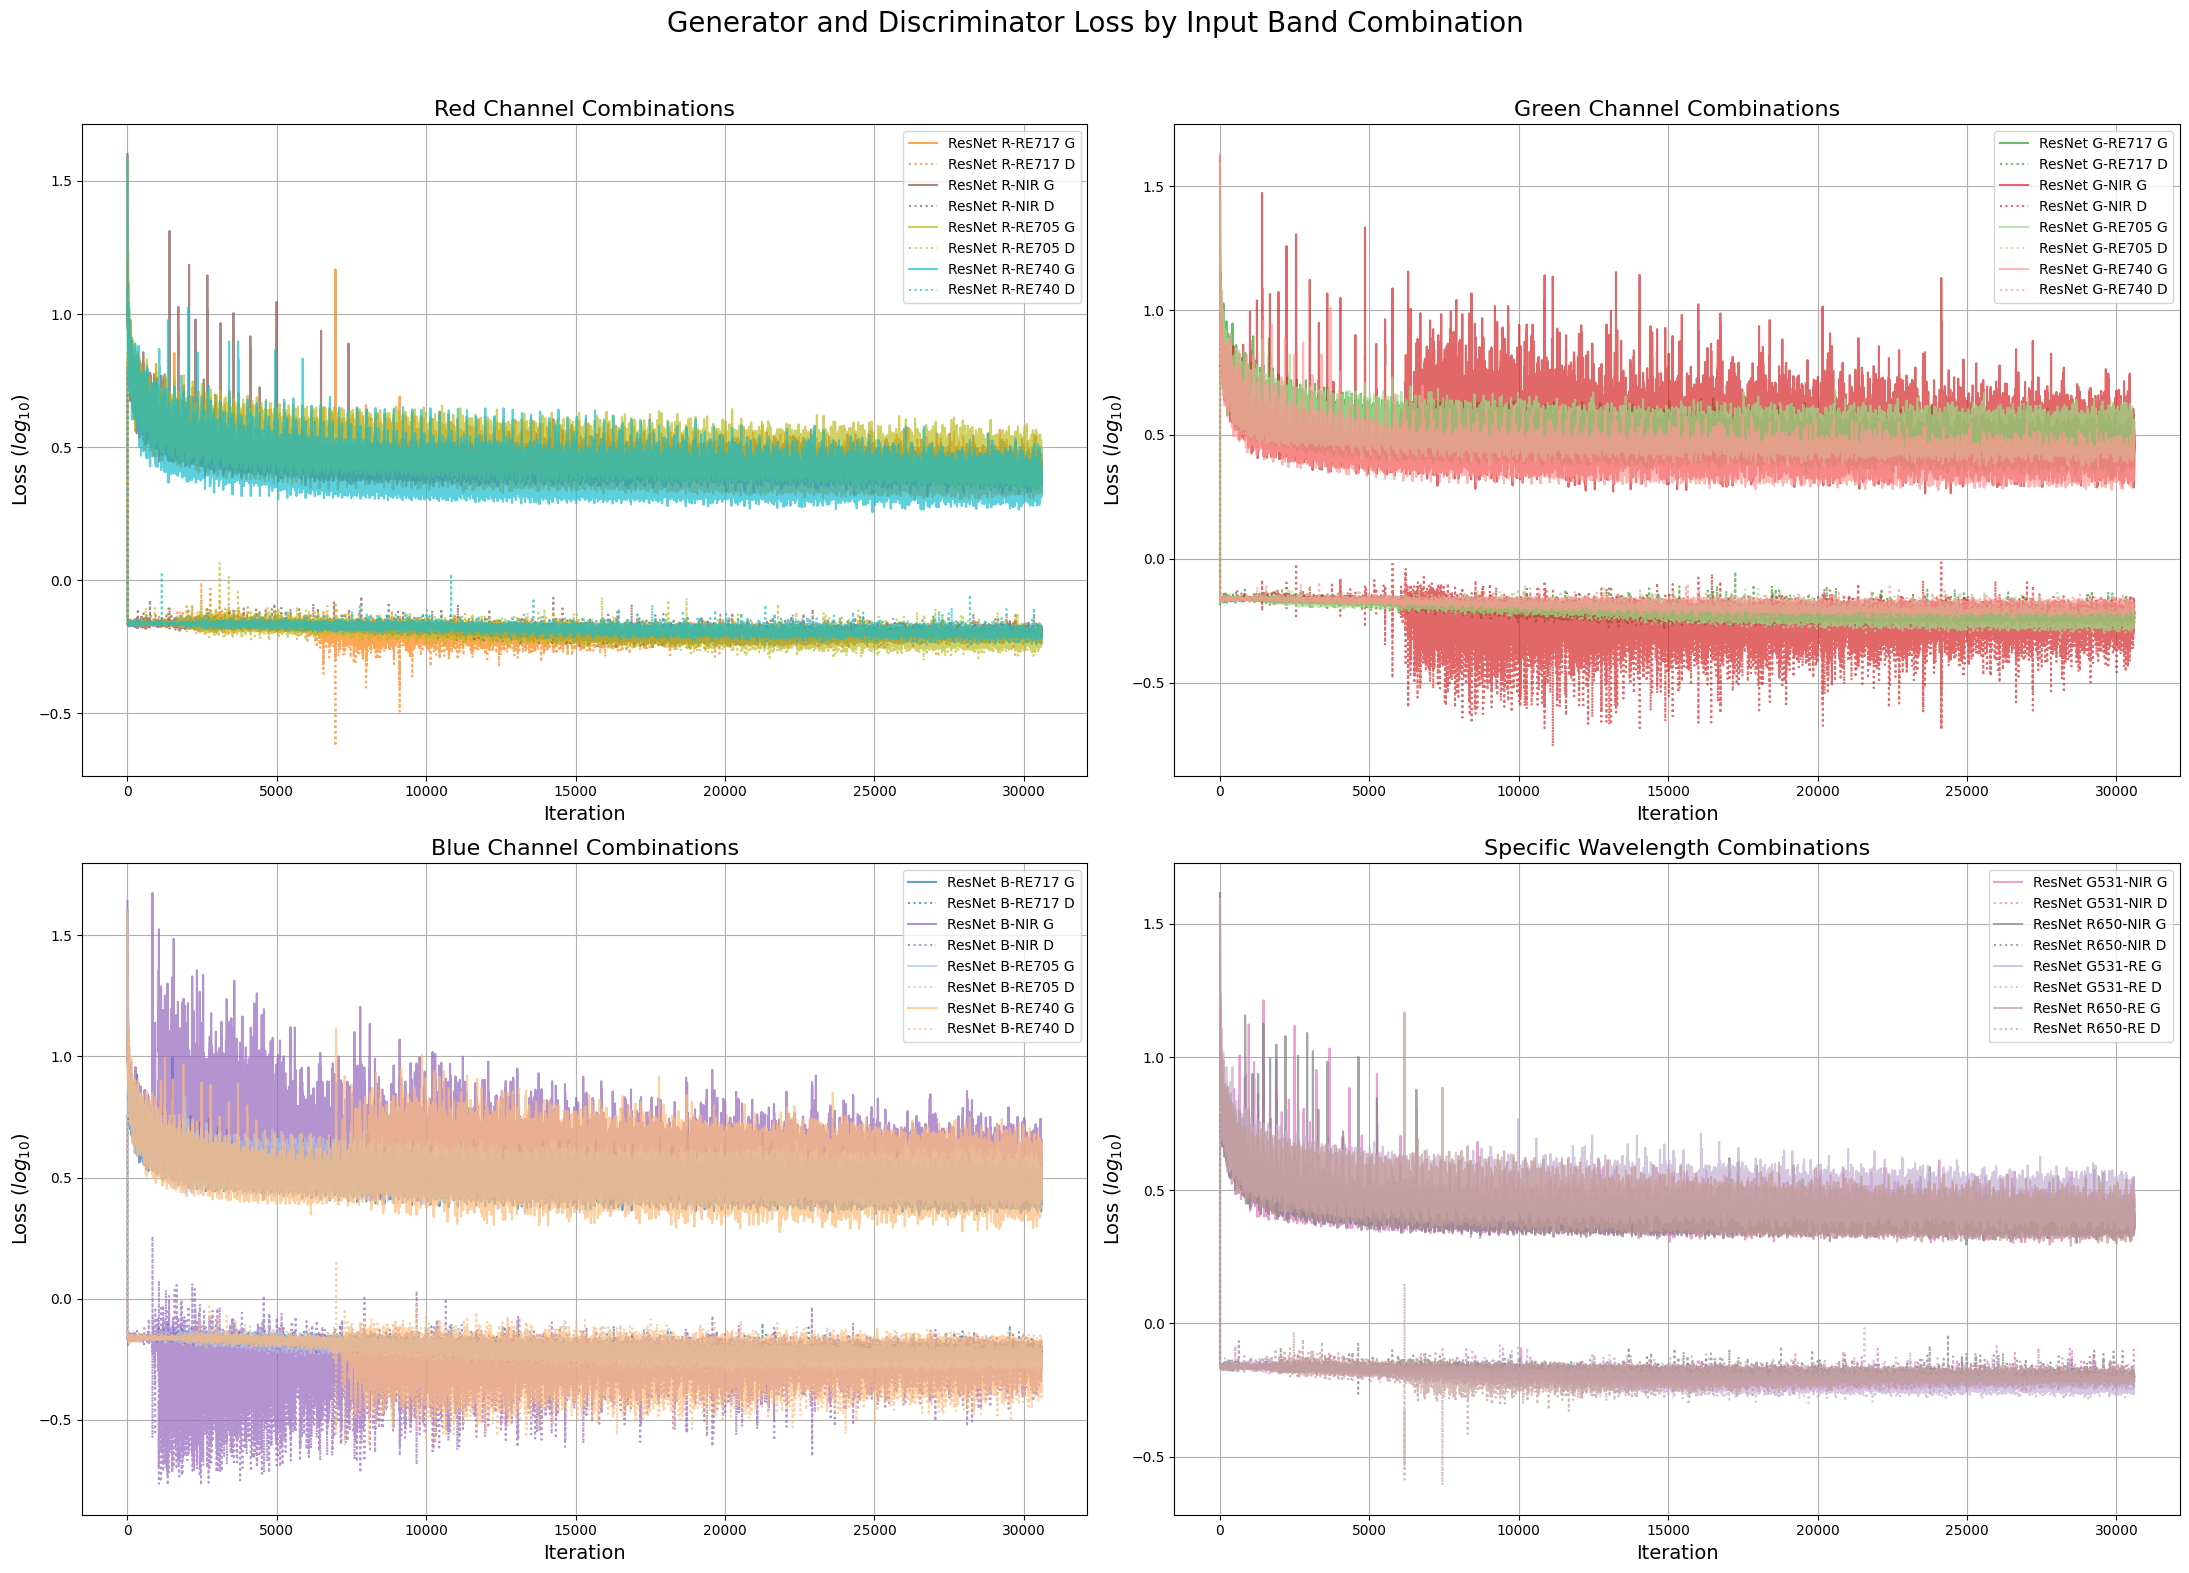

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


new_ordered_scenario_keys = [
    'B-RE717', 'R-RE717', 'G-RE717',
    'G-NIR', 'B-NIR', 'R-NIR',
    'G531-NIR', 'R650-NIR', 'R-RE705',
    'R-RE740', 'B-RE705', 'B-RE740',
    'G-RE705', 'G-RE740', 'G531-RE', 'R650-RE'
]

# 16 new scenarios
new_scenario_color_map = {
    'B-RE717': '#1f77b4', 'R-RE717': '#ff7f0e', 'G-RE717': '#2ca02c',
    'G-NIR': '#d62728', 'B-NIR': '#9467bd', 'R-NIR': '#8c564b',
    'G531-NIR': '#e377c2', 'R650-NIR': '#7f7f7f', 'R-RE705': '#bcbd22',
    'R-RE740': '#17becf', 'B-RE705': '#aec7e8', 'B-RE740': '#ffbb78',
    'G-RE705': '#98df8a', 'G-RE740': '#ff9896', 'G531-RE': '#c5b0d5',
    'R650-RE': '#c49c94', 'default': 'gray'
}



def get_color_for_scenario(model_name, color_map, ordered_keys):
    for scenario_key in ordered_keys:
        if scenario_key in model_name:
            return color_map.get(scenario_key, color_map['default'])
    return color_map['default']

# figure comparing G and D losses for specific band combinations.
def plot_specific_band_generator_and_discriminator(
    B_RE717_list, R_RE717_list, G_RE717_list,
    G_NIR_list, B_NIR_list, R_NIR_list,
    G531_NIR_list, R650_NIR_list, R_RE705_list,
    R_RE740_list, B_RE705_list, B_RE740_list,
    G_RE705_list, G_RE740_list, G531_RE_list, R650_RE_list
):
    fig, axs = plt.subplots(2, 2, figsize=(22, 16))
    fig.suptitle('Generator and Discriminator Loss by Input Band Combination', fontsize=20)


    r_data = R_RE717_list + R_NIR_list + R_RE705_list + R_RE740_list
    g_data = G_RE717_list + G_NIR_list + G_RE705_list + G_RE740_list
    b_data = B_RE717_list + B_NIR_list + B_RE705_list + B_RE740_list
    misc_data = G531_NIR_list + R650_NIR_list + G531_RE_list + R650_RE_list

    plot_configs = [
        {'ax': axs[0, 0], 'data_list': r_data, 'title': 'Red Channel Combinations'},
        {'ax': axs[0, 1], 'data_list': g_data, 'title': 'Green Channel Combinations'},
        {'ax': axs[1, 0], 'data_list': b_data, 'title': 'Blue Channel Combinations'},
        {'ax': axs[1, 1], 'data_list': misc_data, 'title': 'Specific Wavelength Combinations'}
    ]

    opacity_level = 0.7  # Opacity for the plot lines

    for config in plot_configs:
        ax = config['ax']
        data_list = config['data_list']
        title = config['title']

        ax.set_title(title, fontsize=16)
        if not data_list:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Loss ($log_{10}$)')
            ax.grid(True)
            continue

        for i, (model_name, g_loss, d_loss, val_loss, test_loss) in enumerate(data_list):
            iterations = np.arange(1, len(g_loss) + 1)

            model_color = get_color_for_scenario(model_name, new_scenario_color_map, new_ordered_scenario_keys)

            g_loss_np = np.array(g_loss)
            d_loss_np = np.array(d_loss)


            valid_g_indices = g_loss_np > 0
            if np.any(valid_g_indices):
                ax.plot(iterations[valid_g_indices], np.log10(g_loss_np[valid_g_indices]),
                        label=f'{model_name} G', color=model_color, linestyle='-', alpha=opacity_level)


            valid_d_indices = d_loss_np > 0
            if np.any(valid_d_indices):
                ax.plot(iterations[valid_d_indices], np.log10(d_loss_np[valid_d_indices]),
                        label=f'{model_name} D', color=model_color, linestyle=':', alpha=opacity_level)

        ax.set_xlabel('Iteration', fontsize=14)
        ax.set_ylabel('Loss ($log_{10}$)', fontsize=14)
        ax.grid(True)
        ax.legend(fontsize='medium')

    plt.tight_layout(rect=[0, 0, 1, 0.96])


plot_specific_band_generator_and_discriminator(
    B_RE717_list, R_RE717_list, G_RE717_list,
    G_NIR_list, B_NIR_list, R_NIR_list,
    G531_NIR_list, R650_NIR_list, R_RE705_list,
    R_RE740_list, B_RE705_list, B_RE740_list,
    G_RE705_list, G_RE740_list, G531_RE_list, R650_RE_list
)

print("Plot saved as specific_band_generator_discriminator_loss.png")

Plot saved as specific_band_comparisons.png


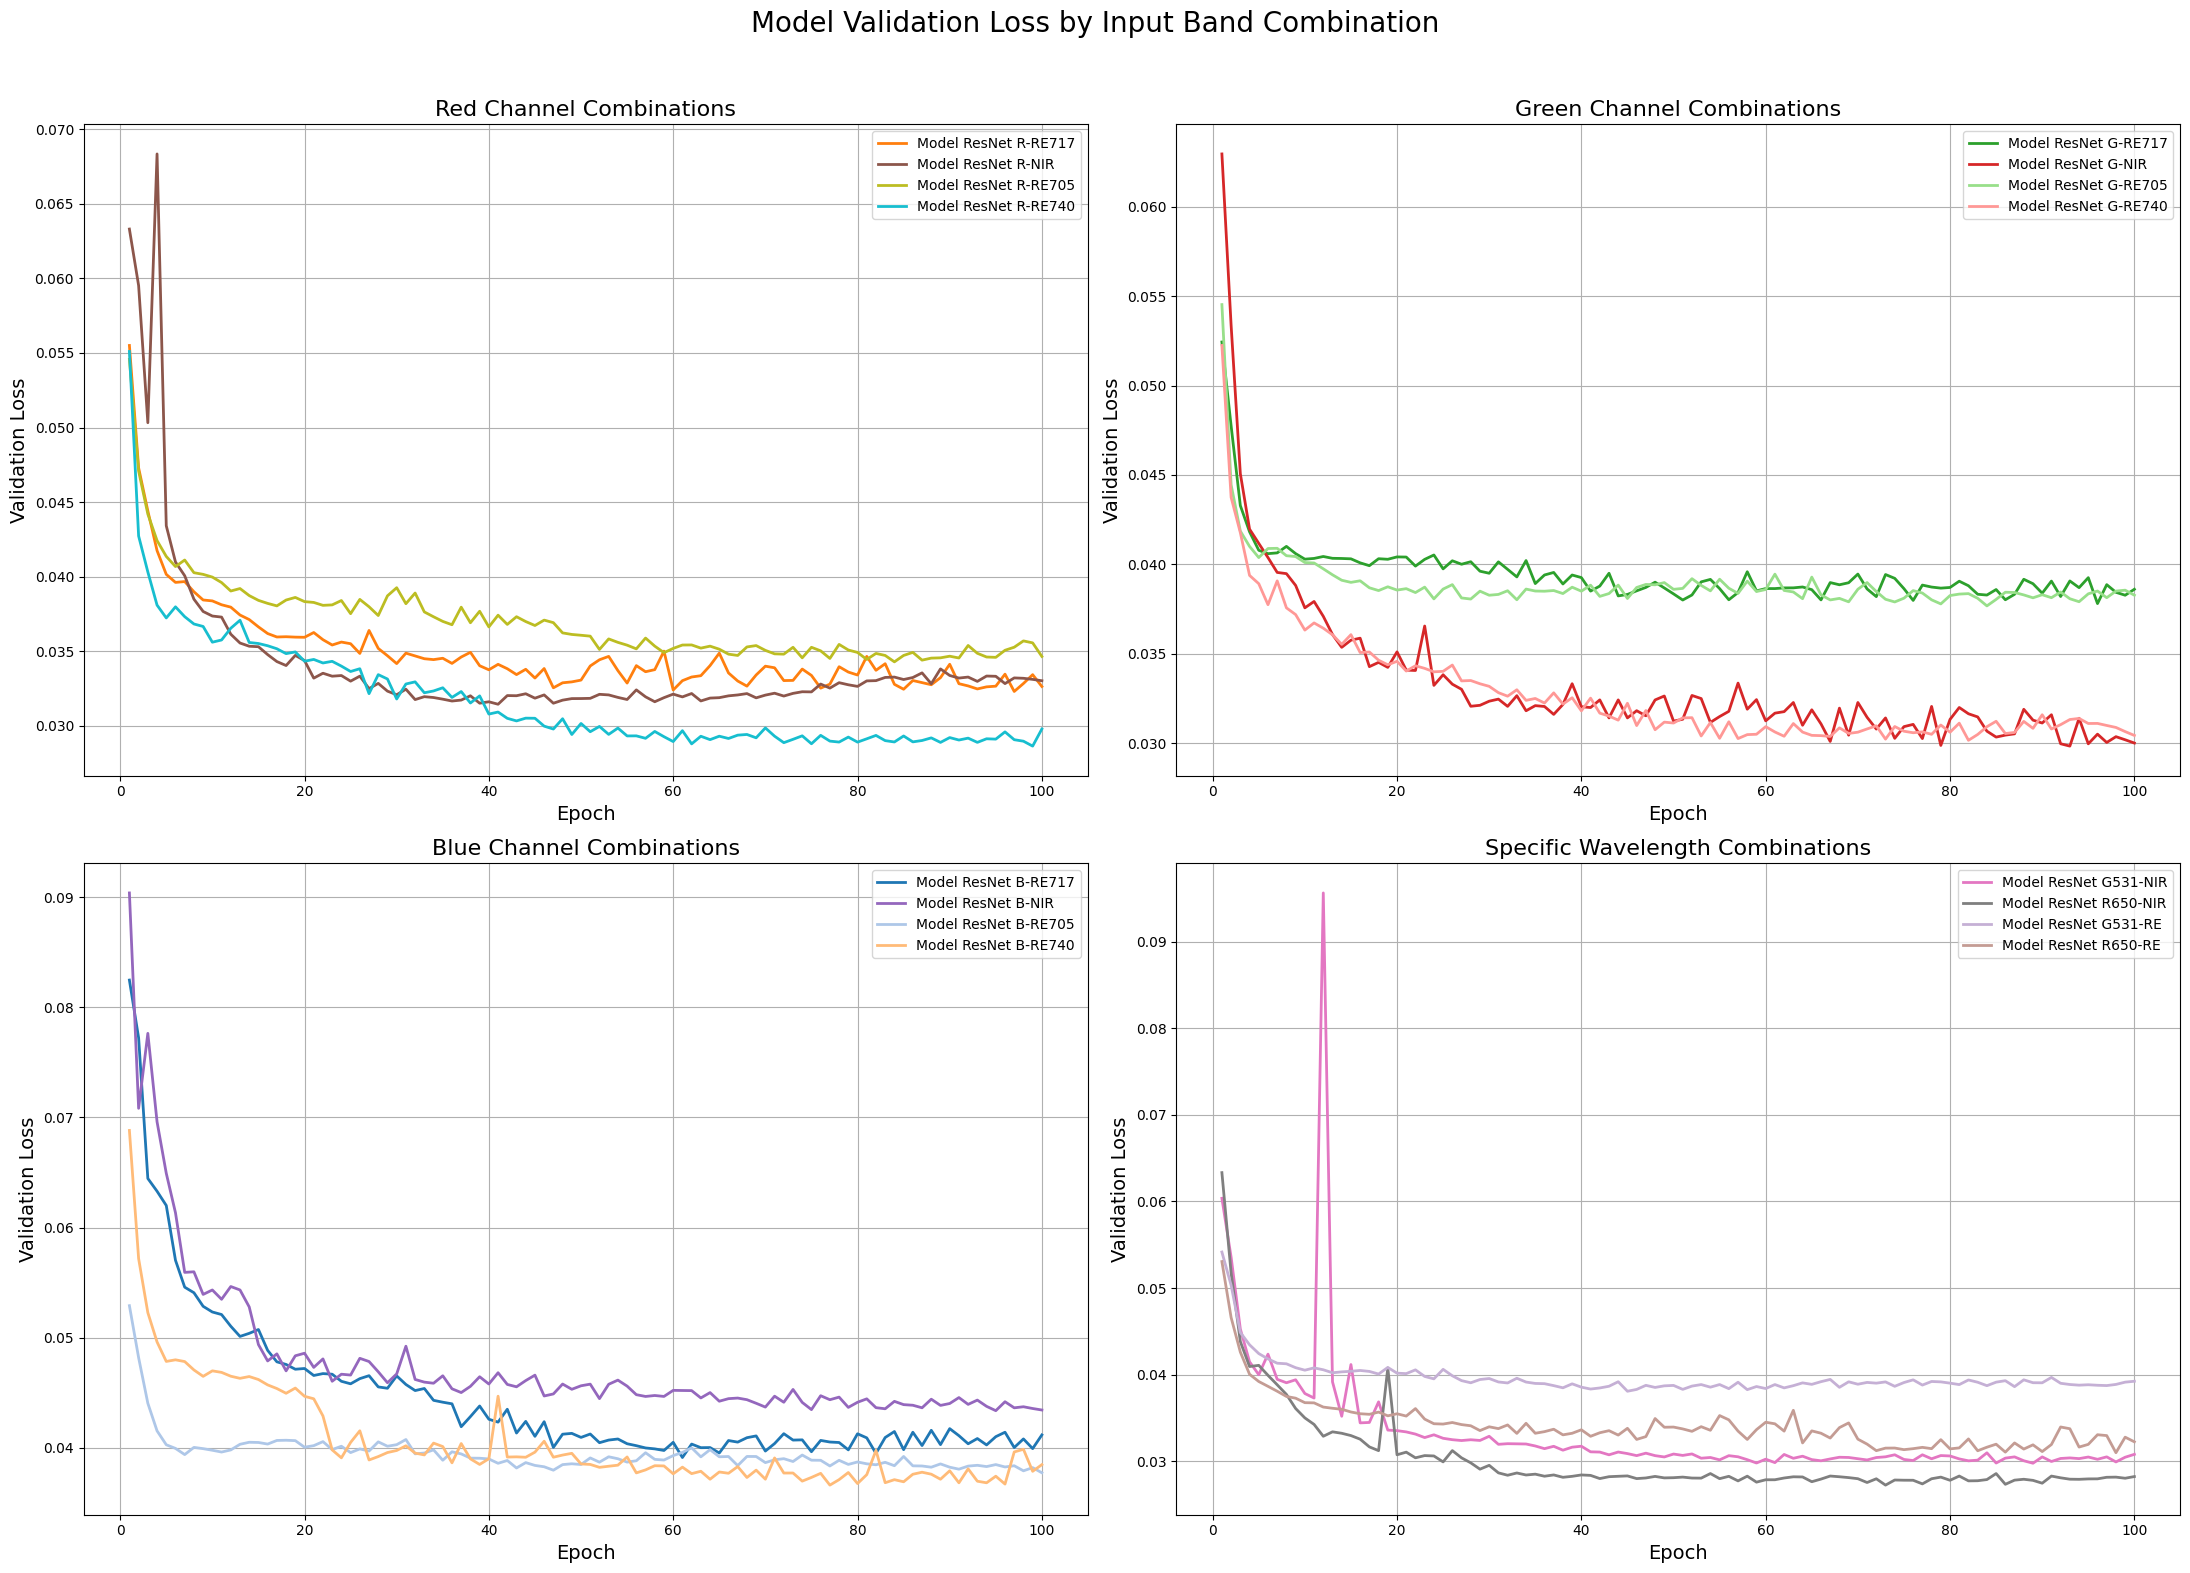

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

new_ordered_scenario_keys = [
    'B-RE717', 'R-RE717', 'G-RE717',
    'G-NIR', 'B-NIR', 'R-NIR',
    'G531-NIR', 'R650-NIR', 'R-RE705',
    'R-RE740', 'B-RE705', 'B-RE740',
    'G-RE705', 'G-RE740', 'G531-RE', 'R650-RE'
]

# 16 new scenarios
new_scenario_color_map = {
    'B-RE717': '#1f77b4', 'R-RE717': '#ff7f0e', 'G-RE717': '#2ca02c',
    'G-NIR': '#d62728', 'B-NIR': '#9467bd', 'R-NIR': '#8c564b',
    'G531-NIR': '#e377c2', 'R650-NIR': '#7f7f7f', 'R-RE705': '#bcbd22',
    'R-RE740': '#17becf', 'B-RE705': '#aec7e8', 'B-RE740': '#ffbb78',
    'G-RE705': '#98df8a', 'G-RE740': '#ff9896', 'G531-RE': '#c5b0d5',
    'R650-RE': '#c49c94', 'default': 'gray'
}


def get_color_for_scenario(model_name, color_map, ordered_keys):
    for scenario_key in ordered_keys:
        if scenario_key in model_name:
            return color_map.get(scenario_key, color_map['default'])
    return color_map['default']

# subplots comparing performance for specific band combinations.
def plot_specific_band_comparisons(
    B_RE717_list, R_RE717_list, G_RE717_list,
    G_NIR_list, B_NIR_list, R_NIR_list,
    G531_NIR_list, R650_NIR_list, R_RE705_list,
    R_RE740_list, B_RE705_list, B_RE740_list,
    G_RE705_list, G_RE740_list, G531_RE_list, R650_RE_list
):
    fig, axs = plt.subplots(2, 2, figsize=(22, 16))
    fig.suptitle('Model Validation Loss by Input Band Combination', fontsize=20)

    # Combine the lists for each subplot
    r_data = R_RE717_list + R_NIR_list + R_RE705_list + R_RE740_list
    g_data = G_RE717_list + G_NIR_list + G_RE705_list + G_RE740_list
    b_data = B_RE717_list + B_NIR_list + B_RE705_list + B_RE740_list
    misc_data = G531_NIR_list + R650_NIR_list + G531_RE_list + R650_RE_list

    plot_configs = [
        {'ax': axs[0, 0], 'data_list': r_data, 'title': 'Red Channel Combinations'},
        {'ax': axs[0, 1], 'data_list': g_data, 'title': 'Green Channel Combinations'},
        {'ax': axs[1, 0], 'data_list': b_data, 'title': 'Blue Channel Combinations'},
        {'ax': axs[1, 1], 'data_list': misc_data, 'title': 'Specific Wavelength Combinations'}
    ]

    for config in plot_configs:
        ax = config['ax']
        data_list = config['data_list']
        title = config['title']

        ax.set_title(title, fontsize=16)
        if not data_list:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Validation Loss')
            ax.grid(True)
            continue

        for i, (model_name, g_loss, d_loss, val_loss, test_loss) in enumerate(data_list):
            epochs = range(1, len(val_loss) + 1)
            color = get_color_for_scenario(model_name, new_scenario_color_map, new_ordered_scenario_keys)
            ax.plot(epochs, val_loss, label=f'Model {model_name}', color=color, linewidth=2)

        ax.set_xlabel('Epoch', fontsize=14)
        ax.set_ylabel('Validation Loss', fontsize=14)
        ax.grid(True)
        ax.legend(fontsize='medium')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("specific_band_comparisons.png")


plot_specific_band_comparisons(
    B_RE717_list, R_RE717_list, G_RE717_list,
    G_NIR_list, B_NIR_list, R_NIR_list,
    G531_NIR_list, R650_NIR_list, R_RE705_list,
    R_RE740_list, B_RE705_list, B_RE740_list,
    G_RE705_list, G_RE740_list, G531_RE_list, R650_RE_list
)

print("Plot saved as specific_band_comparisons.png")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ordered_scenario_keys = [
    'RGB + NIR',
    'Centers + Bandwidth',
    'RGB',
    'PCA',
    'MI',
    'Centers'
]

scenario_color_map = {
    'RGB + NIR': 'red',
    'RGB': 'blue',
    'PCA': 'green',
    'MI': 'purple',
    'Centers': 'orange',
    'Centers + Bandwidth': 'deepskyblue',
    'default': 'gray'
}


def get_color_for_scenario(model_name, color_map, ordered_keys):
    for scenario_key in ordered_keys:
        if scenario_key in model_name:
            return color_map.get(scenario_key, color_map['default'])
    return color_map['default']


#subplots comparing performance across bands
def plot_band_comparisons(MI_list, PCA_list, Bandwidth_list, Micasense_list, fourbands_list, threebands_list):
    fig, axs = plt.subplots(3, 2, figsize=(20, 15))
    fig.suptitle('Model Performance by Input Band Type', fontsize=16)

    plot_configs = [
        {'ax': axs[0,0], 'data_list': MI_list, 'title': 'MI Input', 'expected_scenario': 'MI'},
        {'ax': axs[0,1], 'data_list': PCA_list, 'title': 'PCA Input', 'expected_scenario': 'PCA'},
        {'ax': axs[1,0], 'data_list': Bandwidth_list, 'title': 'Centers + Bandwidth Input', 'expected_scenario': 'Centers + Bandwidth'},
        {'ax': axs[1,1], 'data_list': Micasense_list, 'title': 'Centers Input', 'expected_scenario': 'Centers'},
        {'ax': axs[2,0], 'data_list': fourbands_list, 'title': 'RGB + NIR Input', 'expected_scenario': 'RGB + NIR'},
        {'ax': axs[2,1], 'data_list': threebands_list, 'title': 'RGB Input', 'expected_scenario': 'RGB'}
    ]

    for config in plot_configs:
        ax = config['ax']
        data_list = config['data_list']
        title = config['title']

        ax.set_title(title)
        if not data_list:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Validation Loss')
            ax.grid(True)
            continue

        for i, (new_model_name, g_loss, d_loss, val_loss, test_loss) in enumerate(data_list):
            epochs = range(1, len(val_loss) + 1)
            color = get_color_for_scenario(new_model_name, scenario_color_map, ordered_scenario_keys)
            ax.plot(epochs, val_loss, label=f'Model {new_model_name}', color=color)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.grid(True)
        ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# subplots comparing performance across generator architectures
def plot_generator_comparisons(MLP_list, Large_list, CNN_list, UNet_list, ResNet_list):
    fig, axs = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle('Model Performance by Generator Architecture', fontsize=20)

    axs[2,1].axis('off')

    plot_configs = [
        {'ax': axs[0,0], 'data_list': MLP_list, 'title': 'MLP Generator'},
        {'ax': axs[0,1], 'data_list': Large_list, 'title': 'Cramér Generator'},
        {'ax': axs[1,0], 'data_list': CNN_list, 'title': 'CNN Generator'},
        {'ax': axs[1,1], 'data_list': UNet_list, 'title': 'U-Net Generator'},
        {'ax': axs[2,0], 'data_list': ResNet_list, 'title': 'ResNet Generator'}
    ]

    for config in plot_configs:
        ax = config['ax']
        data_list = config['data_list']
        title = config['title']
        ax.set_title(title, fontsize=16)

        if not data_list:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Validation Loss')
            ax.grid(True)
            continue

        for i, (new_model_name, g_loss, d_loss, val_loss, test_loss) in enumerate(data_list):
            epochs = range(1, len(val_loss) + 1)
            color = get_color_for_scenario(new_model_name, scenario_color_map, ordered_scenario_keys)
            ax.plot(epochs, val_loss, label=f'Model {new_model_name}', color=color)
        ax.set_xlabel('Epoch', fontsize='xx-large')
        ax.set_ylabel('Validation Loss', fontsize='xx-large')
        ax.grid(True)
        ax.legend(fontsize='large')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



def plot_generator_and_discriminator(MLP_list, Large_list, CNN_list, UNet_list, ResNet_list):
    fig, axs = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle('Generator and Discriminator Loss by Architecture', fontsize=20)

    axs[2,1].axis('off')

    plot_configs = [
        {'ax': axs[0,0], 'data_list': MLP_list, 'title': 'MLP Generator'},
        {'ax': axs[0,1], 'data_list': Large_list, 'title': 'Cramér Generator'},
        {'ax': axs[1,0], 'data_list': CNN_list, 'title': 'CNN Generator'},
        {'ax': axs[1,1], 'data_list': UNet_list, 'title': 'U-Net Generator'},
        {'ax': axs[2,0], 'data_list': ResNet_list, 'title': 'ResNet Generator'}
    ]

    opacity_level = 0.6

    for config in plot_configs:
        ax = config['ax']
        data_list = config['data_list']
        title = config['title']
        ax.set_title(title, fontsize=16)

        if not data_list:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Loss ($log_{10}$)')
            ax.grid(True)
            continue

        for i, (new_model_name, g_loss, d_loss, val_loss, test_loss) in enumerate(data_list):
            iterations = np.arange(1, len(g_loss) + 1)
            model_color = get_color_for_scenario(new_model_name, scenario_color_map, ordered_scenario_keys)

            new_model_name = new_model_name.split(' ', 1)[1]



            g_loss_np = np.array(g_loss)
            d_loss_np = np.array(d_loss)

            valid_g_indices = g_loss_np > 0
            if np.any(valid_g_indices):
                ax.plot(iterations[valid_g_indices], np.log10(g_loss_np[valid_g_indices]),
                        label=f'{new_model_name} G', color=model_color, linestyle='-', alpha=opacity_level)
            print(len(g_loss_np))

            valid_d_indices = d_loss_np > 0
            if np.any(valid_d_indices):
                ax.plot(iterations[valid_d_indices], np.log10(d_loss_np[valid_d_indices]),
                        label=f'{new_model_name} D', color=model_color, linestyle=':', alpha=opacity_level)

        ax.set_xlabel('Iteration', fontsize='xx-large')
        ax.set_ylabel('Loss ($log_{10}$)', fontsize='xx-large')
        ax.grid(True)
        ax.legend(loc="upper right", fontsize='large')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_band_comparisons(MI_list, PCA_list, Bandwidth_list, Micasense_list, fourbands_list, threebands_list)
plot_generator_comparisons(MLP_list, Large_list, CNN_list, UNet_list, ResNet)
plot_generator_and_discriminator(MLP_list, Large_list, CNN_list, UNet_list, ResNet)